# Caregiver Cluster Simple Metrics

This notebook gives a simple, local, decision-oriented summary of the caregiver acceptability project. It uses the project's cached REDCap exports, selected cohort file, configuration, and committed audit tables to answer five practical questions:

1. What REDCap API snapshots and study assets exist locally right now?
2. Which fraud-screening fields, branching-logic audit outputs, and trust-tier summaries actually exist in the current project files?
3. How many selected records are usable for clustering?
4. How balanced and how separated is the two-cluster solution?
5. How different is the held-out screening outcome across clusters?

The notebook stays grounded in current project content. It uses deterministic trust-screen outputs and cached REDCap pulls, avoids unsupported bot-rate claims, and keeps the focus on the study objective: whether the caregiver acceptability profiles remain interpretable and decision-useful.

In [1]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.decomposition import PCA

from caregiver_analysis_pipeline import (
    CLUSTER_ORDER,
    _screen_summary,
    _verify_sha_sidecar,
    build_cluster_domains,
    fit_named_kmeans,
    load_config,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 140

PROJECT_DIR = Path.cwd()
CACHE_DIR = PROJECT_DIR / "data_cache"
OUTPUT_DIR = PROJECT_DIR / "Caregiver Outputs"

if not (PROJECT_DIR / "config.yaml").exists():
    raise FileNotFoundError("Run this notebook from the caregiver-cluster-analysis project folder.")

config = load_config(PROJECT_DIR)
palette = {
    "Higher acceptability": config["figures"]["higher_acceptability"],
    "Conditional acceptability": config["figures"]["conditional_acceptability"],
}
accent = config["figures"]["ink"]

def load_latest_cache(project_id: int, content: str = "record") -> tuple[pd.DataFrame, Path]:
    matches = sorted(CACHE_DIR.glob(f"{project_id}_{content}_*.parquet"))
    if not matches:
        raise FileNotFoundError(f"No cached {content} file found for project {project_id}.")
    path = matches[-1]
    _verify_sha_sidecar(path)
    return pd.read_parquet(path), path

def load_output_table(filename: str) -> pd.DataFrame:
    return pd.read_csv(OUTPUT_DIR / filename)

def load_selected_ids() -> pd.Series:
    selected_path = PROJECT_DIR / "cleaned_autism_study_data.csv"
    selected_column = pd.read_csv(selected_path, nrows=0).columns[0]
    return (
        pd.read_csv(selected_path, usecols=[selected_column])[selected_column]
        .pipe(pd.to_numeric, errors="coerce")
        .dropna()
        .astype(int)
        .astype(str)
    )

## 1. REDCap API Snapshot

This project already contains verified local REDCap API cache files for both studies. The notebook does not assume live API access or fresh token availability. Instead, it inspects the current cached `record`, `metadata`, and `instrument` pulls in `data_cache` and shows which study surfaces and fraud-relevant fields are actually present now.

That matters because the realistic analysis path depends on the available data structure. Timing fields, timestamps, and project-specific anti-fraud fields can be used directly; anything not present should not be inferred or back-filled with speculative methodology.

For the new branching-logic audit, the operative 4581 validation surface is the hashed REDCap cache, not the 2026-01-20 CSV fallback in this folder. The cache contains the full 1,779-row legacy project snapshot needed for the manual audit families.

In [2]:
clean_record, clean_record_path = load_latest_cache(4797, "record")
clean_meta, clean_meta_path = load_latest_cache(4797, "metadata")
clean_instrument, clean_instrument_path = load_latest_cache(4797, "instrument")

dirty_record, dirty_record_path = load_latest_cache(4581, "record")
dirty_meta, dirty_meta_path = load_latest_cache(4581, "metadata")
dirty_instrument, dirty_instrument_path = load_latest_cache(4581, "instrument")

selected_ids = load_selected_ids()
analysis_frame = clean_record.loc[clean_record["record_id"].astype(str).isin(selected_ids)].copy()
analysis_frame["record_id"] = analysis_frame["record_id"].astype(str)
analysis_frame["uid"] = "4797_" + analysis_frame["record_id"]
analysis_frame = analysis_frame.set_index("uid", drop=False)

api_inventory = pd.DataFrame(
    [
        {"source_project": "clean_4797", "content": "record", "rows": len(clean_record), "columns": len(clean_record.columns), "cache_file": clean_record_path.name, "origin": "verified cache"},
        {"source_project": "clean_4797", "content": "metadata", "rows": len(clean_meta), "columns": len(clean_meta.columns), "cache_file": clean_meta_path.name, "origin": "verified cache"},
        {"source_project": "clean_4797", "content": "instrument", "rows": len(clean_instrument), "columns": len(clean_instrument.columns), "cache_file": clean_instrument_path.name, "origin": "verified cache"},
        {"source_project": "dirty_4581", "content": "record", "rows": len(dirty_record), "columns": len(dirty_record.columns), "cache_file": dirty_record_path.name, "origin": "verified cache"},
        {"source_project": "dirty_4581", "content": "metadata", "rows": len(dirty_meta), "columns": len(dirty_meta.columns), "cache_file": dirty_meta_path.name, "origin": "verified cache"},
        {"source_project": "dirty_4581", "content": "instrument", "rows": len(dirty_instrument), "columns": len(dirty_instrument.columns), "cache_file": dirty_instrument_path.name, "origin": "verified cache"},
    ]
)

clean_fields = set(clean_meta["field_name"].astype(str))
dirty_fields = set(dirty_meta["field_name"].astype(str))
metadata_summary = pd.DataFrame(
    [
        {"quantity": "shared metadata fields", "n": len(clean_fields & dirty_fields)},
        {"quantity": "4797-only metadata fields", "n": len(clean_fields - dirty_fields)},
        {"quantity": "4581-only metadata fields", "n": len(dirty_fields - clean_fields)},
    ]
)

def field_exists(frame: pd.DataFrame, field: str) -> str:
    return "Yes" if field in frame.columns else "No"

def prefixed_exists(frame: pd.DataFrame, prefix: str) -> str:
    return "Yes" if any(column.startswith(prefix) for column in frame.columns) else "No"

field_availability = pd.DataFrame(
    [
        {"signal": "All four timing fields", "clean_4797": "Yes" if all(field in clean_record.columns for field in ["get_time_fif", "get_time_val", "get_time_tfa", "get_time_demo"]) else "No", "dirty_4581": "Yes" if all(field in dirty_record.columns for field in ["get_time_fif", "get_time_val", "get_time_tfa", "get_time_demo"]) else "No", "why_it_matters": "Supports direct timing-based quality checks without guessed durations"},
        {"signal": "Timestamp columns", "clean_4797": str(sum(column.endswith("_timestamp") for column in clean_record.columns)), "dirty_4581": str(sum(column.endswith("_timestamp") for column in dirty_record.columns)), "why_it_matters": "Supports burst/submission-window checks when present"},
        {"signal": "age_check_demo", "clean_4797": field_exists(clean_record, "age_check_demo"), "dirty_4581": field_exists(dirty_record, "age_check_demo"), "why_it_matters": "Internal age-consistency fraud screen"},
        {"signal": "elig_knee checkbox set", "clean_4797": prefixed_exists(clean_record, "elig_knee___"), "dirty_4581": prefixed_exists(dirty_record, "elig_knee___"), "why_it_matters": "Project-native attention check"},
        {"signal": "email_elig", "clean_4797": field_exists(clean_record, "email_elig"), "dirty_4581": field_exists(dirty_record, "email_elig"), "why_it_matters": "Possible duplicate/disposable-email screening when returned by API"},
        {"signal": "tfa_free_screen", "clean_4797": field_exists(clean_record, "tfa_free_screen"), "dirty_4581": field_exists(dirty_record, "tfa_free_screen"), "why_it_matters": "Held-out outcome used after clustering"},
    ]
)

project_assets = pd.DataFrame(
    [
        {"role": "Project configuration", "path": "config.yaml"},
        {"role": "Selected cohort file", "path": "cleaned_autism_study_data.csv"},
        {"role": "Clean fallback CSV reference", "path": "InfantAutismScreenin-FullDataset_DATA_2026-01-20_0940.csv"},
        {"role": "Clean fallback labeled CSV", "path": "InfantAutismScreenin-FullDataset_DATA_LABELS_2026-01-20_0940.csv"},
        {"role": "Current 4797 record cache", "path": f"data_cache/{clean_record_path.name}"},
        {"role": "Current 4581 record cache", "path": f"data_cache/{dirty_record_path.name}"},
        {"role": "Committed row-level audit artifact", "path": "Caregiver Outputs/record_flags.parquet"},
    ]
)

cohort_inventory = pd.DataFrame(
    [
        {"stage": "4797 cached records", "n": len(clean_record), "note": "Verified-clean project snapshot"},
        {"stage": "4581 cached records", "n": len(dirty_record), "note": "Legacy project snapshot used for branching audit validation"},
        {"stage": "Selected analytic records", "n": len(analysis_frame), "note": "Rows matched from cleaned_autism_study_data.csv"},
    ]
)

display(project_assets)
display(api_inventory)
display(metadata_summary)
display(field_availability)
display(cohort_inventory)

,role,path
0,Project configuration,config.yaml
1,Selected cohort file,cleaned_autism_study_data.csv
2,Clean fallback CSV reference,InfantAutismScreenin-FullDataset_DATA_2026-01-...
3,Clean fallback labeled CSV,InfantAutismScreenin-FullDataset_DATA_LABELS_2...
4,Current 4797 record cache,data_cache/4797_record_2026-09-02.parquet
5,Current 4581 record cache,data_cache/4581_record_2026-09-02.parquet
6,Committed row-level audit artifact,Caregiver Outputs/record_flags.parquet


,source_project,content,rows,columns,cache_file,origin
0,clean_4797,record,177,385,4797_record_2026-09-02.parquet,verified cache
1,clean_4797,metadata,324,18,4797_metadata_2026-09-02.parquet,verified cache
2,clean_4797,instrument,5,2,4797_instrument_2026-09-02.parquet,verified cache
3,dirty_4581,record,1779,369,4581_record_2026-09-02.parquet,verified cache
4,dirty_4581,metadata,315,18,4581_metadata_2026-09-02.parquet,verified cache
5,dirty_4581,instrument,5,2,4581_instrument_2026-09-02.parquet,verified cache


,quantity,n
0,shared metadata fields,311
1,4797-only metadata fields,13
2,4581-only metadata fields,4


,signal,clean_4797,dirty_4581,why_it_matters
0,All four timing fields,Yes,Yes,Supports direct timing-based quality checks wi...
1,Timestamp columns,5,5,Supports burst/submission-window checks when p...
2,age_check_demo,Yes,No,Internal age-consistency fraud screen
3,elig_knee checkbox set,Yes,No,Project-native attention check
4,email_elig,Yes,No,Possible duplicate/disposable-email screening ...
5,tfa_free_screen,Yes,Yes,Held-out outcome used after clustering


,stage,n,note
0,4797 cached records,177,Verified-clean project snapshot
1,4581 cached records,1779,Legacy project snapshot used for branching aud...
2,Selected analytic records,135,Rows matched from cleaned_autism_study_data.csv


## 2. Grounded Metric and Fraud Definitions

This notebook keeps the metric set intentionally small and uses only structures that already exist in the project files: cached REDCap pulls, deterministic rule outputs, the selected cohort file, and committed validation tables.

### Domain scaling
For each survey item that belongs in a TFA domain, the existing pipeline rescales responses to 0 to 100:

$$
\text{score}_{0-100} = \frac{x - \min(x)}{\max(x) - \min(x)} \times 100
$$

Reverse-coded items are flipped after scaling so that higher values always mean more of the domain being named.

### Clusterable rule
A selected caregiver enters clustering only if at least 8 of the 10 domain scores are observed:

$$
\text{clusterable} = \mathbb{1}(\text{non-missing domains} \ge 8)
$$

### Deterministic trust tiers
The fraud screen is deterministic and rule-based. It is a grounded screen of current records, not a bot-rate estimator.

$$
\text{Tier 1} = \mathbb{1}(R1 \lor R2 \lor R5 \lor R8 \lor R9)
$$

$$
\text{suspicion count} = R3 + R4 + R6 + R7
$$

Tier 2 means at least two softer suspicion rules fire and Tier 1 does not. Tier 3 means exactly one softer suspicion rule fires and Tier 1 does not. Tier 4 means none of the tier-defining rules fire. Rule R10 is retained as a validation signal, but it is not tier-defining in this project.

### Cluster separation
The main fit-quality metric is the silhouette score:

$$
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

where $a(i)$ is the mean distance to the respondent's own cluster and $b(i)$ is the mean distance to the nearest other cluster.

### Held-out decision metric
The most decision-useful held-out outcome is the Definitely yes screening rate gap:

$$
\Delta = p_{\text{Higher acceptability}} - p_{\text{Conditional acceptability}}
$$

This remains easy to interpret because screening is not part of the clustering inputs.

## 3. What the Deterministic Fraud Screen Currently Shows

The project already exports a grounded trust screen over all 1,956 cached records. The realistic way to summarize fraud-related evidence here is to show the rule definitions, the rule counts by project, the tier distribution, the rule false-positive rates inside the verified-clean 4797 cohort, and the dedicated branching-logic audit table for the manual 4581 contradiction families.

That keeps the notebook focused on what is actually supported: which records are flagged, how strong the screen is against known-human records, and how much of each project remains in the pass tier. It does **not** try to convert those flags into a literal fraud prevalence.

A concise fraud-case table is also shown for the selected 4797 analytic cohort, limited to Tier 1 and Tier 2 records only. The branching-logic audit case table is kept separate and tied to the hashed 4581 cache because the January CSV in this folder is the clean fallback rather than the full legacy-project extract.

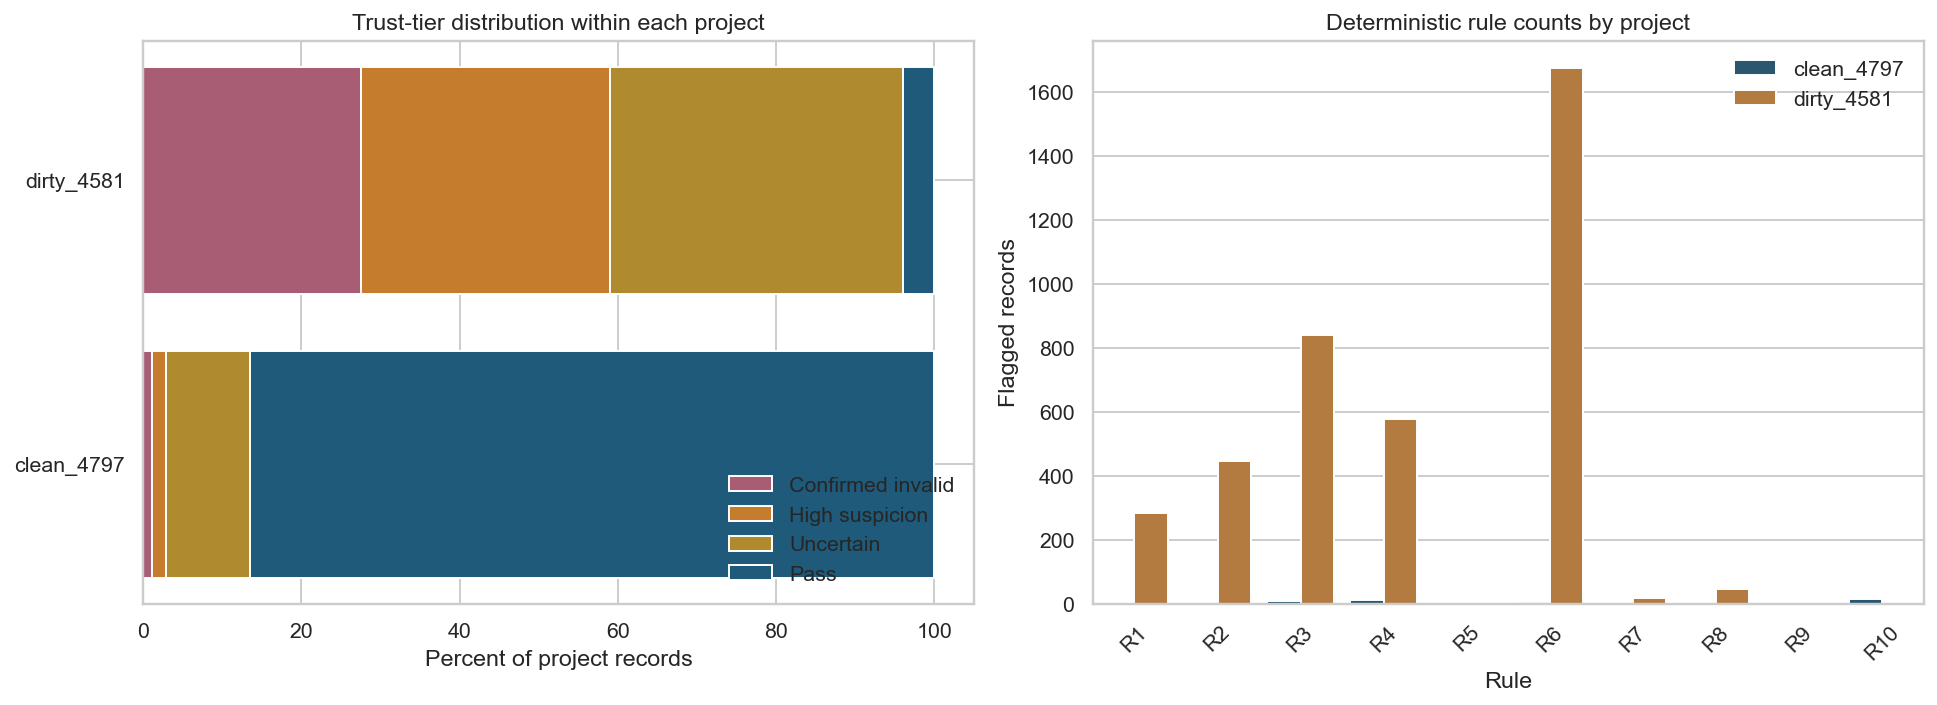

,source_project,Confirmed invalid,High suspicion,Uncertain,Pass,total_n,high_suspicion_or_worse_n,high_suspicion_or_worse_pct
0,clean_4797,2,3,19,153,177,5,2.82
1,dirty_4581,489,560,660,70,1779,1049,58.97


,case_uid,trust_tier,status_quo_cluster,soft_suspicion_rules_n,triggered_rules
100,4797_101,Confirmed invalid,Higher acceptability,0,R9
88,4797_89,Confirmed invalid,Conditional acceptability,0,R9
142,4797_143,High suspicion,Conditional acceptability,2,"R3, R4"


,rule,definition,threshold
0,R1,Total time below verified-human floor,11.57
1,R2,TFA time below verified-human floor,7.85
2,R3,Any instrument below clean 1st percentile,"{""feat_time_demo"": 1.1, ""feat_time_fif"": 0.786..."
3,R4,Within-block response SD at/below clean 1st pe...,"{""feat_sd_likert_4"": 0.777678586912093, ""feat_..."
4,R5,Exact ordered Likert fingerprint duplicate,0.8
5,R6,At least 3 submissions in clean-derived short ...,60.0
6,R7,Near-duplicate open text,0.9
7,R8,Logical family-information inconsistency,logical
8,R9,Impossible demographic combination,logical
9,R10,4797 instrument-native anti-fraud gate (valida...,logical


,rule,flagged_n,false_positive_pct
0,R1,0,0.00
1,R2,0,0.00
2,R3,6,4.58
3,R4,5,3.82
4,R5,0,0.00
5,R6,3,2.29
6,R7,0,0.00
7,R8,0,0.00
8,R9,2,1.53
9,R10,10,7.63


In [3]:
rule_definitions = load_output_table("table_14_fraud_rule_definitions.csv")
false_positive = load_output_table("table_15_rule_false_positive_rates.csv")
rule_counts = load_output_table("table_15b_rule_counts_by_project.csv")
tier_counts = load_output_table("table_16_trust_tier_counts.csv")
record_flags = pd.read_parquet(OUTPUT_DIR / "record_flags.parquet")

fraud_overview = (
    tier_counts.pivot(index="source_project", columns="tier_label", values="n")
    .fillna(0)
    .reset_index()
)
fraud_overview.columns.name = None
fraud_overview["total_n"] = fraud_overview.drop(columns=["source_project"]).sum(axis=1)
fraud_overview["high_suspicion_or_worse_n"] = (
    fraud_overview.get("Confirmed invalid", 0) + fraud_overview.get("High suspicion", 0)
)
fraud_overview["high_suspicion_or_worse_pct"] = (
    fraud_overview["high_suspicion_or_worse_n"] / fraud_overview["total_n"] * 100
)
fraud_overview = fraud_overview[
    [
        "source_project",
        "Confirmed invalid",
        "High suspicion",
        "Uncertain",
        "Pass",
        "total_n",
        "high_suspicion_or_worse_n",
        "high_suspicion_or_worse_pct",
    ]
]

rule_cols = [f"rule_R{i}" for i in range(1, 11)]
selected_uid = {"4797_" + record_id for record_id in selected_ids}
tier12_case_table = (
    record_flags.loc[
        record_flags["uid"].isin(selected_uid) & record_flags["tier"].isin([1, 2]),
        [
            "uid",
            "source_project",
            "tier",
            "tier_label",
            "cluster_status_quo",
            "suspicion_rule_count",
            *rule_cols,
        ],
    ]
    .copy()
    .sort_values(["tier", "uid"])
)
tier12_case_table["triggered_rules"] = tier12_case_table[rule_cols].apply(
    lambda row: ", ".join(
        column.replace("rule_", "") for column, value in row.items() if bool(value)
    ),
    axis=1,
)
tier12_case_table = tier12_case_table[
    [
        "uid",
        "tier_label",
        "cluster_status_quo",
        "suspicion_rule_count",
        "triggered_rules",
    ]
].rename(
    columns={
        "uid": "case_uid",
        "tier_label": "trust_tier",
        "cluster_status_quo": "status_quo_cluster",
        "suspicion_rule_count": "soft_suspicion_rules_n",
    }
)

rule_plot = rule_counts.melt(
    id_vars="rule",
    value_vars=["clean_4797_n", "dirty_4581_n"],
    var_name="source_project",
    value_name="n",
)
rule_plot["source_project"] = rule_plot["source_project"].map(
    {"clean_4797_n": "clean_4797", "dirty_4581_n": "dirty_4581"}
)

tier_order = ["Confirmed invalid", "High suspicion", "Uncertain", "Pass"]
tier_colors = {
    "Confirmed invalid": config["figures"]["pink"],
    "High suspicion": config["figures"]["orange"],
    "Uncertain": config["figures"]["gold"],
    "Pass": config["figures"]["blue"],
}

tier_plot = (
    tier_counts.pivot(index="source_project", columns="tier_label", values="pct_within_project")
    .reindex(index=["clean_4797", "dirty_4581"], columns=tier_order)
    .fillna(0)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
left = pd.Series(0.0, index=tier_plot.index)
for label in tier_order:
    axes[0].barh(
        tier_plot.index,
        tier_plot[label],
        left=left,
        color=tier_colors[label],
        label=label,
    )
    left = left + tier_plot[label]
axes[0].set_title("Trust-tier distribution within each project")
axes[0].set_xlabel("Percent of project records")
axes[0].legend(frameon=False, loc="lower right")

sns.barplot(
    data=rule_plot,
    x="rule",
    y="n",
    hue="source_project",
    palette={"clean_4797": config["figures"]["blue"], "dirty_4581": config["figures"]["orange"]},
    ax=axes[1],
)
axes[1].set_title("Deterministic rule counts by project")
axes[1].set_xlabel("Rule")
axes[1].set_ylabel("Flagged records")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

display(fraud_overview.round(2))
display(tier12_case_table)
display(rule_definitions[["rule", "definition", "threshold"]])
display(false_positive[["rule", "flagged_n", "false_positive_pct"]].round(2))

### 3a. Branching-Logic Audit Cases

The generalized `R8` rule now writes a dedicated branching-audit table from the hashed REDCap cache. The new prenatal-testing and earlier-diagnosis contradiction families are intentionally scoped to the dirty 4581 audit cohort so they can be reviewed against the manual bot-screen findings without contaminating the verified-clean 4797 human reference.

The summary below focuses on those manual audit families and keeps the older age-band-count `R8` check visible as legacy context rather than mixing it into the manual contradiction counts.

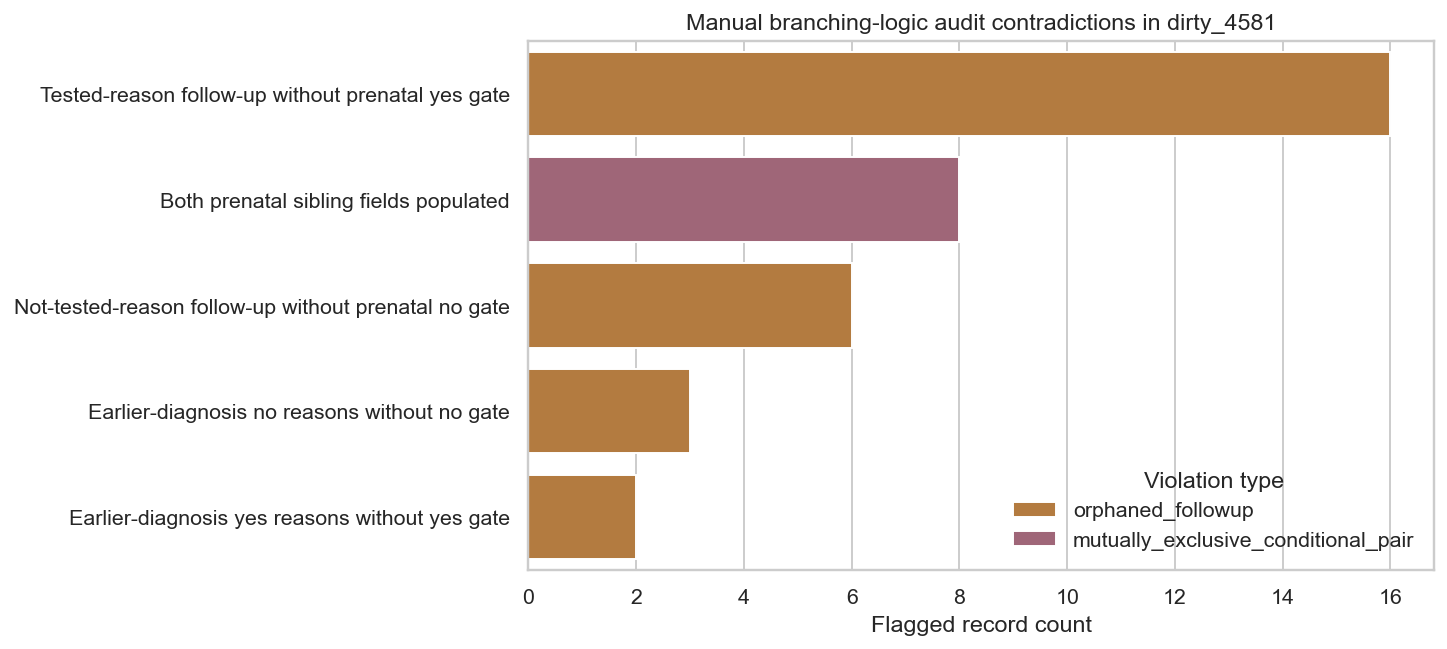

,family_label,violation_type,flagged_records_n
4,Tested-reason follow-up without prenatal yes gate,orphaned_followup,16
0,Both prenatal sibling fields populated,mutually_exclusive_conditional_pair,8
3,Not-tested-reason follow-up without prenatal n...,orphaned_followup,6
1,Earlier-diagnosis no reasons without no gate,orphaned_followup,3
2,Earlier-diagnosis yes reasons without yes gate,orphaned_followup,2


,dirty_4581_record_id,audit_family,audit_type,expected_branching_logic,saved_gate_values,saved_conflicting_values
41,31,Both prenatal sibling fields populated,mutually_exclusive_conditional_pair,"([fif_pregnant] <> """" and [fif_pregnant]=1) | ...","{""fif_pregnant"": ""1""}","{""fif_prenatal_no_preg"": ""1"", ""fif_prenatal_pr..."
37,118,Both prenatal sibling fields populated,mutually_exclusive_conditional_pair,"([fif_pregnant] <> """" and [fif_pregnant]=1) | ...","{""fif_pregnant"": ""1""}","{""fif_prenatal_no_preg"": ""1"", ""fif_prenatal_pr..."
40,273,Both prenatal sibling fields populated,mutually_exclusive_conditional_pair,"([fif_pregnant] <> """" and [fif_pregnant]=1) | ...","{""fif_pregnant"": ""0""}","{""fif_prenatal_no_preg"": ""1"", ""fif_prenatal_pr..."
42,571,Both prenatal sibling fields populated,mutually_exclusive_conditional_pair,"([fif_pregnant] <> """" and [fif_pregnant]=1) | ...","{""fif_pregnant"": ""1""}","{""fif_prenatal_no_preg"": ""1"", ""fif_prenatal_pr..."
43,768,Both prenatal sibling fields populated,mutually_exclusive_conditional_pair,"([fif_pregnant] <> """" and [fif_pregnant]=1) | ...","{""fif_pregnant"": ""0""}","{""fif_prenatal_no_preg"": ""0"", ""fif_prenatal_pr..."
36,1076,Both prenatal sibling fields populated,mutually_exclusive_conditional_pair,"([fif_pregnant] <> """" and [fif_pregnant]=1) | ...","{""fif_pregnant"": ""1""}","{""fif_prenatal_no_preg"": ""1"", ""fif_prenatal_pr..."
38,1554,Both prenatal sibling fields populated,mutually_exclusive_conditional_pair,"([fif_pregnant] <> """" and [fif_pregnant]=1) | ...","{""fif_pregnant"": ""0""}","{""fif_prenatal_no_preg"": ""0"", ""fif_prenatal_pr..."
39,1699,Both prenatal sibling fields populated,mutually_exclusive_conditional_pair,"([fif_pregnant] <> """" and [fif_pregnant]=1) | ...","{""fif_pregnant"": ""0""}","{""fif_prenatal_no_preg"": ""0"", ""fif_prenatal_pr..."
9,1137,Earlier-diagnosis no reasons without no gate,orphaned_followup,"([fif_diag_earlier] <> """" and [fif_diag_earlie...","{""fif_diag_earlier"": ""1""}","{""fif_diag_early_no___1"": ""1"", ""fif_diag_early..."
10,1642,Earlier-diagnosis no reasons without no gate,orphaned_followup,"([fif_diag_earlier] <> """" and [fif_diag_earlie...","{""fif_diag_earlier"": ""1""}","{""fif_diag_early_no___1"": ""0"", ""fif_diag_early..."


,legacy_r8_family,flagged_records_n
0,Legacy R8 age-band count check,9


In [4]:
branching_audit = load_output_table("table_34_branching_logic_audit.csv")
manual_branching_families = [
    "prenatal_testing_mutually_exclusive_pair",
    "prenatal_tested_reason_without_prenatal_yes",
    "prenatal_not_tested_reason_without_prenatal_no",
    "earlier_diagnosis_yes_reason_without_yes_gate",
    "earlier_diagnosis_no_reason_without_no_gate",
]
family_labels = {
    "prenatal_testing_mutually_exclusive_pair": "Both prenatal sibling fields populated",
    "prenatal_tested_reason_without_prenatal_yes": "Tested-reason follow-up without prenatal yes gate",
    "prenatal_not_tested_reason_without_prenatal_no": "Not-tested-reason follow-up without prenatal no gate",
    "earlier_diagnosis_yes_reason_without_yes_gate": "Earlier-diagnosis yes reasons without yes gate",
    "earlier_diagnosis_no_reason_without_no_gate": "Earlier-diagnosis no reasons without no gate",
    "child_age_band_count_exceeds_child_count": "Legacy R8 age-band count check",
}
manual_branching_audit = branching_audit.loc[
    branching_audit["family"].isin(manual_branching_families)
] .copy()
manual_branching_audit["family_label"] = manual_branching_audit["family"].map(family_labels)
branching_summary = (
    manual_branching_audit.groupby(["family_label", "violation_type"], as_index=False)
    .agg(flagged_records_n=("record_id", "nunique"))
    .sort_values(["flagged_records_n", "family_label"], ascending=[False, True])
)
branching_case_table = (
    manual_branching_audit[
        [
            "record_id",
            "family_label",
            "violation_type",
            "gating_logic",
            "gating_values",
            "observed_values",
        ]
    ]
    .rename(
        columns={
            "record_id": "dirty_4581_record_id",
            "family_label": "audit_family",
            "violation_type": "audit_type",
            "gating_logic": "expected_branching_logic",
            "gating_values": "saved_gate_values",
            "observed_values": "saved_conflicting_values",
        }
    )
    .sort_values(["audit_family", "dirty_4581_record_id"])
)
legacy_r8_summary = (
    branching_audit.loc[~branching_audit["family"].isin(manual_branching_families)]
    .groupby("family", as_index=False)
    .agg(flagged_records_n=("record_id", "nunique"))
)
legacy_r8_summary["family"] = legacy_r8_summary["family"].map(family_labels).fillna(legacy_r8_summary["family"])

fig, ax = plt.subplots(figsize=(10.5, 4.8))
sns.barplot(
    data=branching_summary,
    x="flagged_records_n",
    y="family_label",
    hue="violation_type",
    palette={
        "mutually_exclusive_conditional_pair": config["figures"]["pink"],
        "orphaned_followup": config["figures"]["orange"],
    },
    ax=ax,
)
ax.set_title("Manual branching-logic audit contradictions in dirty_4581")
ax.set_xlabel("Flagged record count")
ax.set_ylabel("")
ax.legend(frameon=False, title="Violation type")
plt.tight_layout()
plt.show()

display(branching_summary)
display(branching_case_table)
if not legacy_r8_summary.empty:
    display(legacy_r8_summary.rename(columns={"family": "legacy_r8_family"}))

### 3b. Tier 1 Overlap and Gift-Card Verification Workflow

This section converts deterministic trust-screen evidence into an operational participant-verification workflow for gift cards.

The policy is intentionally conservative and avoids direct bot labels:
- **Auto-eligible**: no Tier 1 hits and Tier 4 pass.
- **Eligible with low-risk review**: no Tier 1 hits and Tier 3 (one soft suspicion rule).
- **Manual review queue**: single Tier 1 hit, Tier 2 soft-signal concentration, or multi-hit timing-only patterns.
- **Do not pay pending adjudication**: multi-hit Tier 1 records with hard logical contradictions (R8/R9) or very high Tier 1 burden ($\ge 3$ hits).

Outputs are written on every run so downstream gift-card operations can use stable files:
- `table_37_bot_declaration_policy.csv`
- `table_38_dirty4581_review_queue.csv`
- `table_39_dirty4581_giftcard_eligible_provisional.csv`
- `figure_22_tier1_overlap_heatmap.png`

These files support IRB-safe operations by using rule evidence and REDCap record IDs only; no direct email fields are used in notebook outputs.

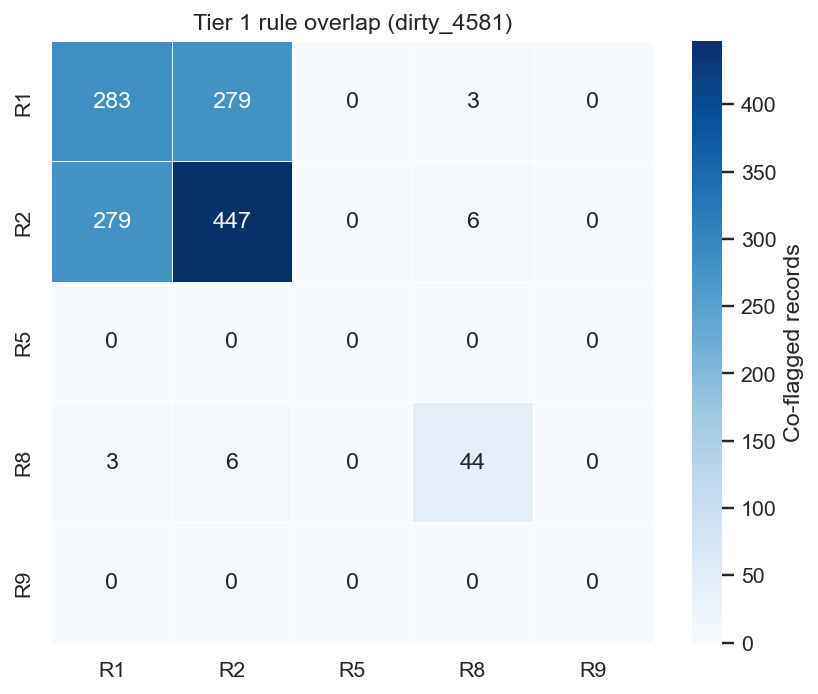

,source_project,giftcard_decision,records_n,pct_within_project
0,clean_4797,auto_eligible,153,86.44
1,clean_4797,eligible_low_risk_review,19,10.73
2,clean_4797,manual_review,5,2.82
6,dirty_4581,manual_review,1043,58.63
5,dirty_4581,eligible_low_risk_review,660,37.10
3,dirty_4581,auto_eligible,70,3.93
4,dirty_4581,do_not_pay_pending_adjudication,6,0.34


,source_project,n_records,tier1_any_hit_n,tier1_ge2_n,tier1_ge3_n,tier1_all5_n,tier1_any_hit_pct,tier1_ge2_pct,tier1_ge3_pct,tier1_all5_pct
0,clean_4797,177,2,0,0,0,1.130,0.000,0.000,0.0
1,dirty_4581,1779,489,282,3,0,27.487,15.852,0.169,0.0


,source_project,tier1_rule_combo,tier1_hit_count,n_records,pct_within_project
2,dirty_4581,none,0,1290,72.513
3,dirty_4581,R1+R2,2,276,15.514
4,dirty_4581,R2,1,165,9.275
5,dirty_4581,R8,1,38,2.136
6,dirty_4581,R1,1,4,0.225
7,dirty_4581,R1+R2+R8,3,3,0.169
8,dirty_4581,R2+R8,2,3,0.169


,uid,record_id,tier,tier_label,tier1_hit_count,tier1_rule_combo,tier1_triggered_rules,soft_triggered_rules,giftcard_decision,decision_reason,in_manual_branching_audit,adjudication_decision,adjudication_notes,adjudicator
1199,4581_1026,1026,1,Confirmed invalid,3,R1+R2+R8,"R1, R2, R8","R3, R4, R6",do_not_pay_pending_adjudication,Three or more Tier 1 rule hits,True,,,
293,4581_120,120,1,Confirmed invalid,3,R1+R2+R8,"R1, R2, R8","R3, R4, R6",do_not_pay_pending_adjudication,Three or more Tier 1 rule hits,False,,,
744,4581_571,571,1,Confirmed invalid,3,R1+R2+R8,"R1, R2, R8","R3, R4, R6",do_not_pay_pending_adjudication,Three or more Tier 1 rule hits,True,,,
1175,4581_1002,1002,1,Confirmed invalid,2,R1+R2,"R1, R2","R3, R6",manual_review,Multiple Tier 1 hits without hard logical cont...,False,,,
1179,4581_1006,1006,1,Confirmed invalid,2,R1+R2,"R1, R2","R3, R4, R6",manual_review,Multiple Tier 1 hits without hard logical cont...,False,,,
1181,4581_1008,1008,1,Confirmed invalid,2,R1+R2,"R1, R2","R3, R6",manual_review,Multiple Tier 1 hits without hard logical cont...,False,,,
1183,4581_1010,1010,1,Confirmed invalid,2,R1+R2,"R1, R2","R3, R6",manual_review,Multiple Tier 1 hits without hard logical cont...,False,,,
1200,4581_1027,1027,1,Confirmed invalid,2,R1+R2,"R1, R2","R3, R6",manual_review,Multiple Tier 1 hits without hard logical cont...,False,,,
1211,4581_1038,1038,1,Confirmed invalid,2,R1+R2,"R1, R2","R3, R6",manual_review,Multiple Tier 1 hits without hard logical cont...,False,,,
1212,4581_1039,1039,1,Confirmed invalid,2,R1+R2,"R1, R2","R3, R6",manual_review,Multiple Tier 1 hits without hard logical cont...,False,,,


,uid,record_id,tier,tier_label,tier1_hit_count,tier1_rule_combo,soft_triggered_rules,giftcard_decision,decision_reason
274,4581_101,101,3,Uncertain,0,none,R6,eligible_low_risk_review,Tier 3 with no Tier 1 rule hits; one soft susp...
1186,4581_1013,1013,3,Uncertain,0,none,R6,eligible_low_risk_review,Tier 3 with no Tier 1 rule hits; one soft susp...
1187,4581_1014,1014,3,Uncertain,0,none,R6,eligible_low_risk_review,Tier 3 with no Tier 1 rule hits; one soft susp...
275,4581_102,102,3,Uncertain,0,none,R6,eligible_low_risk_review,Tier 3 with no Tier 1 rule hits; one soft susp...
1193,4581_1020,1020,3,Uncertain,0,none,R6,eligible_low_risk_review,Tier 3 with no Tier 1 rule hits; one soft susp...
1194,4581_1021,1021,3,Uncertain,0,none,R6,eligible_low_risk_review,Tier 3 with no Tier 1 rule hits; one soft susp...
1201,4581_1028,1028,3,Uncertain,0,none,R6,eligible_low_risk_review,Tier 3 with no Tier 1 rule hits; one soft susp...
276,4581_103,103,3,Uncertain,0,none,R6,eligible_low_risk_review,Tier 3 with no Tier 1 rule hits; one soft susp...
1208,4581_1035,1035,3,Uncertain,0,none,R6,eligible_low_risk_review,Tier 3 with no Tier 1 rule hits; one soft susp...
1210,4581_1037,1037,3,Uncertain,0,none,R6,eligible_low_risk_review,Tier 3 with no Tier 1 rule hits; one soft susp...


In [5]:
import numpy as np

tier1_record_overlap = load_output_table("table_36_tier1_record_overlap.csv")
tier1_project_summary = load_output_table("table_36c_tier1_project_summary.csv")
tier1_combo_summary = load_output_table("table_36b_tier1_rule_combo_summary.csv")
record_flags = pd.read_parquet(OUTPUT_DIR / "record_flags.parquet")
branching_audit = load_output_table("table_34_branching_logic_audit.csv")

tier1_rule_cols = ["rule_R1", "rule_R2", "rule_R5", "rule_R8", "rule_R9"]
soft_rule_cols = ["rule_R3", "rule_R4", "rule_R6", "rule_R7"]

decision_frame = record_flags[[
    "uid",
    "source_project",
    "project_id",
    "record_id",
    "tier",
    "tier_label",
    "suspicion_rule_count",
    *tier1_rule_cols,
    *soft_rule_cols,
]].copy()
decision_frame["record_id"] = decision_frame["record_id"].astype(str)

tier1_overlap = tier1_record_overlap[[
    "source_project",
    "project_id",
    "record_id",
    "tier1_hit_count",
    "tier1_rule_combo",
    "tier1_any_hit",
    "tier1_hard_candidate_ge2",
    "tier1_hard_candidate_ge3",
    "tier1_all_5_hits",
]].copy()
tier1_overlap["record_id"] = tier1_overlap["record_id"].astype(str)

decision_frame = decision_frame.merge(
    tier1_overlap,
    on=["source_project", "project_id", "record_id"],
    how="left",
    validate="one_to_one",
)

for col in ["tier1_hit_count"]:
    decision_frame[col] = decision_frame[col].fillna(0).astype(int)
for col in ["tier1_any_hit", "tier1_hard_candidate_ge2", "tier1_hard_candidate_ge3", "tier1_all_5_hits"]:
    decision_frame[col] = decision_frame[col].fillna(False).astype(bool)
decision_frame["tier1_rule_combo"] = decision_frame["tier1_rule_combo"].fillna("none")

decision_frame["hard_logic_hit"] = decision_frame[["rule_R8", "rule_R9"]].any(axis=1)
decision_frame["tier1_triggered_rules"] = decision_frame[tier1_rule_cols].apply(
    lambda row: ", ".join(col.replace("rule_", "") for col, val in row.items() if bool(val)) or "none",
    axis=1,
)
decision_frame["soft_triggered_rules"] = decision_frame[soft_rule_cols].apply(
    lambda row: ", ".join(col.replace("rule_", "") for col, val in row.items() if bool(val)) or "none",
    axis=1,
)

def assign_decision(row: pd.Series) -> str:
    if row["tier1_hit_count"] == 0 and int(row["tier"]) == 4:
        return "auto_eligible"
    if row["tier1_hit_count"] == 0 and int(row["tier"]) == 3:
        return "eligible_low_risk_review"
    if row["tier1_hit_count"] >= 3:
        return "do_not_pay_pending_adjudication"
    if row["tier1_hit_count"] >= 2 and bool(row["hard_logic_hit"]):
        return "do_not_pay_pending_adjudication"
    if row["tier1_hit_count"] >= 2:
        return "manual_review"
    if row["tier1_hit_count"] == 1:
        return "manual_review"
    if int(row["tier"]) in (1, 2):
        return "manual_review"
    return "manual_review"

def decision_reason(row: pd.Series) -> str:
    if row["giftcard_decision"] == "auto_eligible":
        return "Tier 4 with no Tier 1 rule hits"
    if row["giftcard_decision"] == "eligible_low_risk_review":
        return "Tier 3 with no Tier 1 rule hits; one soft suspicion rule only"
    if row["giftcard_decision"] == "do_not_pay_pending_adjudication" and row["tier1_hit_count"] >= 3:
        return "Three or more Tier 1 rule hits"
    if row["giftcard_decision"] == "do_not_pay_pending_adjudication" and bool(row["hard_logic_hit"]):
        return "Multiple Tier 1 hits including hard logical contradiction (R8/R9)"
    if row["giftcard_decision"] == "manual_review" and row["tier1_hit_count"] >= 2:
        return "Multiple Tier 1 hits without hard logical contradiction"
    if row["giftcard_decision"] == "manual_review" and row["tier1_hit_count"] == 1:
        return "Single Tier 1 hit requires adjudication"
    return "Tier 1 clear but non-pass trust tier requires adjudication"

decision_frame["giftcard_decision"] = decision_frame.apply(assign_decision, axis=1)
decision_frame["decision_reason"] = decision_frame.apply(decision_reason, axis=1)

policy_summary = (
    decision_frame.groupby(["source_project", "giftcard_decision"], as_index=False)
    .agg(records_n=("uid", "size"))
    .sort_values(["source_project", "records_n"], ascending=[True, False])
)
policy_summary["pct_within_project"] = policy_summary.groupby("source_project")["records_n"].transform(
    lambda x: x / x.sum() * 100
)

manual_families = [
    "prenatal_testing_mutually_exclusive_pair",
    "prenatal_tested_reason_without_prenatal_yes",
    "prenatal_not_tested_reason_without_prenatal_no",
    "earlier_diagnosis_yes_reason_without_yes_gate",
    "earlier_diagnosis_no_reason_without_no_gate",
]
manual_audit_ids = set(
    branching_audit.loc[branching_audit["family"].isin(manual_families), "record_id"].astype(str)
)

dirty_review_queue = decision_frame.loc[
    (decision_frame["source_project"].eq("dirty_4581"))
    & (decision_frame["giftcard_decision"].isin(["manual_review", "do_not_pay_pending_adjudication"])),
    [
        "uid",
        "record_id",
        "tier",
        "tier_label",
        "tier1_hit_count",
        "tier1_rule_combo",
        "tier1_triggered_rules",
        "soft_triggered_rules",
        "giftcard_decision",
        "decision_reason",
    ],
]
dirty_review_queue["in_manual_branching_audit"] = dirty_review_queue["record_id"].isin(manual_audit_ids)
dirty_review_queue["adjudication_decision"] = ""
dirty_review_queue["adjudication_notes"] = ""
dirty_review_queue["adjudicator"] = ""
dirty_review_queue = dirty_review_queue.sort_values(["tier1_hit_count", "record_id"], ascending=[False, True])

dirty_provisional_eligible = decision_frame.loc[
    (decision_frame["source_project"].eq("dirty_4581"))
    & (decision_frame["giftcard_decision"].isin(["auto_eligible", "eligible_low_risk_review"])),
    [
        "uid",
        "record_id",
        "tier",
        "tier_label",
        "tier1_hit_count",
        "tier1_rule_combo",
        "soft_triggered_rules",
        "giftcard_decision",
        "decision_reason",
    ],
]
dirty_provisional_eligible = dirty_provisional_eligible.sort_values(["tier", "record_id"])

policy_summary.to_csv(OUTPUT_DIR / "table_37_bot_declaration_policy.csv", index=False)
dirty_review_queue.to_csv(OUTPUT_DIR / "table_38_dirty4581_review_queue.csv", index=False)
dirty_provisional_eligible.to_csv(
    OUTPUT_DIR / "table_39_dirty4581_giftcard_eligible_provisional.csv", index=False
)

# Tier-1 overlap heatmap for dirty_4581
dirty_tier1 = decision_frame.loc[decision_frame["source_project"].eq("dirty_4581"), tier1_rule_cols].astype(int)
co_occurrence = dirty_tier1.T @ dirty_tier1
co_occurrence.index = [idx.replace("rule_", "") for idx in co_occurrence.index]
co_occurrence.columns = [idx.replace("rule_", "") for idx in co_occurrence.columns]

fig, ax = plt.subplots(figsize=(6.3, 5.1))
sns.heatmap(
    co_occurrence,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Co-flagged records"},
    ax=ax,
    square=True,
)
ax.set_title("Tier 1 rule overlap (dirty_4581)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figure_22_tier1_overlap_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

display(policy_summary.round(2))
display(tier1_project_summary.round(3))
display(
    tier1_combo_summary.loc[tier1_combo_summary["source_project"].eq("dirty_4581")].head(12).round(3)
)
display(dirty_review_queue.head(15))
display(dirty_provisional_eligible.head(15))

### 3c. Final Showcase Table (Gift-Card Decision Ready)

This is the final stakeholder-facing summary. It keeps only the highest-value metrics from the rule architecture and applies explicit priority weighting to evidence strength.

Priority weighting used for triage:
- **High-priority logic contradictions:** R8/R9
- **Medium-priority timing violations:** R1/R2
- **Supportive pattern signal:** R5

Decision buckets shown below:
- **Provisional real caregivers**: no hard Tier 1 evidence requiring adjudication.
- **Manual review required**: evidence exists but not strong enough for automatic hold.
- **Hold pending adjudication**: strongest evidence concentration, highest risk for invalid participation.

A short, plain-language inference is attached to each flagged record.

In [6]:
decision_bucket_map = {
    "auto_eligible": "Provisional real caregiver",
    "eligible_low_risk_review": "Provisional real caregiver",
    "manual_review": "Manual review required",
    "do_not_pay_pending_adjudication": "Hold pending adjudication",
}

source_project_label_map = {
    "clean_4797": "Source Project 4797",
    "dirty_4581": "Source Project 4581",
}

showcase_frame = decision_frame.copy()
showcase_frame["decision_bucket"] = showcase_frame["giftcard_decision"].map(decision_bucket_map)
showcase_frame["source_project_label"] = showcase_frame["source_project"].map(source_project_label_map).fillna(
    showcase_frame["source_project"]
)

# Priority-weighted evidence score: logic contradictions > timing > duplication
showcase_frame["priority_score"] = (
    showcase_frame["rule_R8"].astype(int) * 5
    + showcase_frame["rule_R9"].astype(int) * 5
    + showcase_frame["rule_R1"].astype(int) * 3
    + showcase_frame["rule_R2"].astype(int) * 3
    + showcase_frame["rule_R5"].astype(int) * 2
)

def brief_inference(row: pd.Series) -> str:
    rules_hit = [
        rule for rule in ["R8", "R9", "R1", "R2", "R5"]
        if bool(row.get(f"rule_{rule}", False))
    ]
    if row["giftcard_decision"] == "do_not_pay_pending_adjudication":
        return (
            f"Flagged high risk: {', '.join(rules_hit) if rules_hit else 'multiple Tier 1 rules'} triggered; "
            "payment held until human adjudication confirms validity."
        )
    if row["giftcard_decision"] == "manual_review":
        if int(row["tier1_hit_count"]) >= 2:
            return (
                f"Flagged for review: multiple Tier 1 rules ({', '.join(rules_hit)}) triggered; "
                "manual verification needed before payment."
            )
        return (
            f"Flagged for review: single Tier 1 trigger ({', '.join(rules_hit)}) detected; "
            "review protects against false positives."
        )
    return "No high-priority rule contradiction detected; provisionally eligible for gift-card workflow."

showcase_frame["decision_inference"] = showcase_frame.apply(brief_inference, axis=1)

final_showcase_summary = (
    showcase_frame.groupby(["source_project_label", "decision_bucket"], as_index=False)
    .agg(records_n=("uid", "size"))
)
final_showcase_summary["pct_within_project"] = final_showcase_summary.groupby("source_project_label")[
    "records_n"
].transform(lambda values: values / values.sum() * 100)

final_showcase_summary = (
    final_showcase_summary.pivot(
        index="source_project_label",
        columns="decision_bucket",
        values="records_n",
    )
    .fillna(0)
    .astype(int)
    .reset_index()
)
final_showcase_summary.columns.name = None

for column in [
    "Provisional real caregiver",
    "Manual review required",
    "Hold pending adjudication",
]:
    if column not in final_showcase_summary.columns:
        final_showcase_summary[column] = 0

final_showcase_summary["total_records"] = (
    final_showcase_summary["Provisional real caregiver"]
    + final_showcase_summary["Manual review required"]
    + final_showcase_summary["Hold pending adjudication"]
)
final_showcase_summary["provisional_real_pct"] = (
    final_showcase_summary["Provisional real caregiver"]
    / final_showcase_summary["total_records"]
    * 100
).round(1)

final_showcase_summary = final_showcase_summary[[
    "source_project_label",
    "Provisional real caregiver",
    "Manual review required",
    "Hold pending adjudication",
    "provisional_real_pct",
]].rename(
    columns={
        "source_project_label": "Source project [from record_flags.source_project]",
        "Provisional real caregiver": "Provisionally eligible for gift card n [auto_eligible + eligible_low_risk_review; source: decision_frame.giftcard_decision]",
        "Manual review required": "Needs manual review n [giftcard_decision == manual_review; source: decision_frame]",
        "Hold pending adjudication": "Payment hold pending adjudication n [giftcard_decision == do_not_pay_pending_adjudication; source: decision_frame]",
        "provisional_real_pct": "Provisionally eligible % [provisional_eligible_n / total source project records x 100; source: decision_frame]",
    }
)

flagged_inference_panel = showcase_frame.loc[
    showcase_frame["decision_bucket"].isin(["Manual review required", "Hold pending adjudication"]),
    [
        "source_project_label",
        "record_id",
        "decision_bucket",
        "priority_score",
        "tier1_triggered_rules",
        "decision_inference",
    ],
]
flagged_inference_panel = flagged_inference_panel.rename(
    columns={
        "source_project_label": "Source project",
        "tier1_triggered_rules": "Rules triggered",
        "decision_bucket": "Decision bucket",
        "priority_score": "Priority score",
        "decision_inference": "Why flagged (1-2 line inference)",
    }
)
flagged_inference_panel = flagged_inference_panel.sort_values(
    ["Priority score", "Source project", "record_id"], ascending=[False, True, True]
).reset_index(drop=True)

combo_distribution_showcase = tier1_combo_summary.copy()
combo_distribution_showcase["source_project"] = combo_distribution_showcase["source_project"].map(
    source_project_label_map
).fillna(combo_distribution_showcase["source_project"])
combo_distribution_showcase = combo_distribution_showcase.rename(
    columns={
        "source_project": "Source project [from table_36b_tier1_rule_combo_summary.source_project]",
        "tier1_rule_combo": "Tier 1 rule combo case [from table_36b_tier1_rule_combo_summary.tier1_rule_combo]",
        "tier1_hit_count": "Tier 1 hits in combo [count of R1/R2/R5/R8/R9 in combo]",
        "n_records": "Cases n [from table_36b_tier1_rule_combo_summary.n_records]",
        "pct_within_project": "Cases % within source project [n_records / source project total x 100; source: table_36b_tier1_rule_combo_summary]",
    }
)
combo_distribution_showcase = combo_distribution_showcase.sort_values(
    [
        "Source project [from table_36b_tier1_rule_combo_summary.source_project]",
        "Cases n [from table_36b_tier1_rule_combo_summary.n_records]",
        "Tier 1 rule combo case [from table_36b_tier1_rule_combo_summary.tier1_rule_combo]",
    ],
    ascending=[True, False, True],
).reset_index(drop=True)

final_showcase_summary.to_csv(OUTPUT_DIR / "table_40_final_showcase_summary.csv", index=False)
flagged_inference_panel.to_csv(OUTPUT_DIR / "table_40b_flagged_inference_panel.csv", index=False)
combo_distribution_showcase.to_csv(
    OUTPUT_DIR / "table_40c_tier1_combo_distribution_showcase.csv",
    index=False,
)

display(final_showcase_summary)
display(flagged_inference_panel.head(20))
display(combo_distribution_showcase)

,Source project [from record_flags.source_project],Provisionally eligible for gift card n [auto_eligible + eligible_low_risk_review; source: decision_frame.giftcard_decision],Needs manual review n [giftcard_decision == manual_review; source: decision_frame],Payment hold pending adjudication n [giftcard_decision == do_not_pay_pending_adjudication; source: decision_frame],Provisionally eligible % [provisional_eligible_n / total source project records x 100; source: decision_frame]
0,Source Project 4581,730,1043,6,41.0
1,Source Project 4797,172,5,0,97.2


,Source project,record_id,Decision bucket,Priority score,Rules triggered,Why flagged (1-2 line inference)
0,Source Project 4581,1026,Hold pending adjudication,11,"R1, R2, R8","Flagged high risk: R8, R1, R2 triggered; payme..."
1,Source Project 4581,120,Hold pending adjudication,11,"R1, R2, R8","Flagged high risk: R8, R1, R2 triggered; payme..."
2,Source Project 4581,571,Hold pending adjudication,11,"R1, R2, R8","Flagged high risk: R8, R1, R2 triggered; payme..."
3,Source Project 4581,1678,Hold pending adjudication,8,"R2, R8","Flagged high risk: R8, R2 triggered; payment h..."
4,Source Project 4581,1774,Hold pending adjudication,8,"R2, R8","Flagged high risk: R8, R2 triggered; payment h..."
5,Source Project 4581,182,Hold pending adjudication,8,"R2, R8","Flagged high risk: R8, R2 triggered; payment h..."
6,Source Project 4581,1002,Manual review required,6,"R1, R2","Flagged for review: multiple Tier 1 rules (R1,..."
7,Source Project 4581,1006,Manual review required,6,"R1, R2","Flagged for review: multiple Tier 1 rules (R1,..."
8,Source Project 4581,1008,Manual review required,6,"R1, R2","Flagged for review: multiple Tier 1 rules (R1,..."
9,Source Project 4581,1010,Manual review required,6,"R1, R2","Flagged for review: multiple Tier 1 rules (R1,..."


,Source project [from table_36b_tier1_rule_combo_summary.source_project],Tier 1 rule combo case [from table_36b_tier1_rule_combo_summary.tier1_rule_combo],Tier 1 hits in combo [count of R1/R2/R5/R8/R9 in combo],Cases n [from table_36b_tier1_rule_combo_summary.n_records],Cases % within source project [n_records / source project total x 100; source: table_36b_tier1_rule_combo_summary]
0,Source Project 4581,none,0,1290,72.512648
1,Source Project 4581,R1+R2,2,276,15.514334
2,Source Project 4581,R2,1,165,9.274874
3,Source Project 4581,R8,1,38,2.136031
4,Source Project 4581,R1,1,4,0.224845
5,Source Project 4581,R1+R2+R8,3,3,0.168634
6,Source Project 4581,R2+R8,2,3,0.168634
7,Source Project 4797,none,0,175,98.870056
8,Source Project 4797,R9,1,2,1.129944


## A. Stakeholder Bot Analysis

This section keeps the bot-analysis story narrow and meeting-ready. It focuses on two deliverables only:

- a simplified notebook walkthrough with clear workflow diagrams, timing plots, overlap views, and plain-English tables
- one Excel workbook with separate sheets for all records, cleared-now records, low-risk provisional approvals, manual review records, extreme-fast records, and confirmed bots

All counts are built from the current row-level classification table, committed rule flags, and the latest cached REDCap record pulls so the notebook and workbook stay aligned.

### A.1 Screening Workflow Pipeline

The next cell prints the current Study 2 workflow directly from the latest stakeholder tables instead of relying on slide text or fixed counts. That keeps three meeting questions visible in one place:

1. Where the 1,779 Study 2 responses split across hard-check review, soft-check review, provisional approval, and clear-pass records.
2. Where the 6 confirmed bots sit in that workflow.
3. How the 279 extreme-fast records fit into the hard-check path, including the 276 that have no other hard-check signal.

Two plain-English tables are shown with the diagram:

- an all-record overview across both studies
- a Study 2 workflow count table for the legacy 4581 review path

In [7]:
from pathlib import Path
import importlib

import matplotlib.pyplot as plt
from IPython.display import display
import bot_analysis as bot_analysis_module

importlib.reload(bot_analysis_module)

from bot_analysis import (
    build_stakeholder_views,
    export_stakeholder_excel,
    plot_category_summary,
    plot_clear_vs_review_demographics,
    plot_completion_time_histogram,
    plot_detailed_breakdown,
    plot_rule_overlap_heatmap,
    plot_rule_violation_frequency,
)

PROJECT_DIR = Path.cwd()
CACHE_DIR = PROJECT_DIR / "data_cache"
OUTPUT_DIR = PROJECT_DIR / "Caregiver Outputs"

stakeholder_views = build_stakeholder_views(OUTPUT_DIR, CACHE_DIR)
master_summary = stakeholder_views["master_summary"]
overview_summary = stakeholder_views["overview_summary"]
workflow_summary = stakeholder_views["workflow_summary"]
workflow_diagram = stakeholder_views["workflow_diagram"]
detailed_breakdown = stakeholder_views["detailed_breakdown"]
confirmed_bots = stakeholder_views["confirmed_bots"]
record_flags = stakeholder_views["record_flags"]
stakeholder_records = stakeholder_views["stakeholder_records"]
study2_records = stakeholder_records.loc[stakeholder_records["source_project"].eq("dirty_4581")].copy()
cleared_records = stakeholder_views["cleared_records"]
low_risk_records = stakeholder_views["low_risk_records"]
review_records = stakeholder_views["review_records"]
confirmed_bot_records = stakeholder_views["confirmed_bot_records"]
extreme_fast_records = stakeholder_views["extreme_fast_records"]
demographic_comparison = stakeholder_views["demographic_comparison"]

print("Stakeholder bot analysis views loaded.")
print(f"All records: {len(stakeholder_records):,}")
print(f"Cleared for payment now: {len(cleared_records):,}")
print(f"Low-risk provisional approval: {len(low_risk_records):,}")
print(f"Needs human review: {len(review_records):,}")
print(f"Confirmed bots / reject: {len(confirmed_bot_records):,}")
print(f"Extreme fast (R1 + R2): {len(extreme_fast_records):,}")

print()
print(workflow_diagram)
display(overview_summary)
display(workflow_summary)

Stakeholder bot analysis views loaded.
All records: 1,956
Cleared for payment now: 223
Low-risk provisional approval: 679
Needs human review: 1,048
Confirmed bots / reject: 6
Extreme fast (R1 + R2): 279

┌──────────────────────────────────────────────┐
│ 1779 Study 2 responses (Project 4581)     │
└──────────────────────┬───────────────────────┘
                       │
                       ▼
┌──────────────────────────────────────────────┐
│ Hard checks: R1, R2, R5, R8, R9  ->  489 │
└───────────────┬──────────────────┬───────────┘
                │                  │
                ▼                  ▼
      Needs review from hard   Confirmed bot / reject
      checks:  483               6

┌──────────────────────────────────────────────┐
│ No hard check -> apply soft checks (R3, R4,  │
│ R6, R7)                                      │
└───────────────┬──────────────────┬───────────┘
                │                  │
                ▼                  ▼
      Needs human review 

,Stakeholder Group,Study 1 (4797),Study 2 (4581),All Records,Interpretation
0,Cleared for payment now,153,70,223,Tier 4 pass. No screening rule fired.
1,Low-risk provisional approval,19,660,679,One soft check only. Provisionally safe but st...
2,Needs human review,5,1043,1048,Manual adjudication queue.
3,Confirmed bot / reject,0,6,6,Strongest evidence concentration. Hold payment.
4,Extreme fast (R1 + R2),0,279,279,Cross-cut subset of the hard-check path; not a...
5,Extreme fast with no other hard check,0,276,276,"Broke both timing rules, but no duplicate or l..."


,Step,Study 2 Count,How to read it
0,Study 2 raw responses,1779,Starting pool for the legacy 4581 review.
1,"Hard-check failures (R1, R2, R5, R8, R9)",489,Records that triggered at least one hard check.
2,Needs human review from hard checks,483,Hard-check records that are still reviewable r...
3,Confirmed bots / reject,6,Strongest evidence concentration; do not pay u...
4,Soft-check review only (no hard check),560,"Two or more soft checks, but no hard-check tri..."
5,Low-risk provisional approval,660,Exactly one soft check and no hard checks.
6,Cleared for payment now,70,Tier 4 pass with no hard or soft screen trigger.
7,Extreme fast: broke both R1 and R2,279,Cross-cut subset; these records are inside the...
8,Extreme fast with no other hard check,276,"Fast on both timing rules, but no duplicate or..."


### A.2 Category Summary

Every record falls into one of four categories based on the screening rules. The table and chart below show the breakdown across both studies.


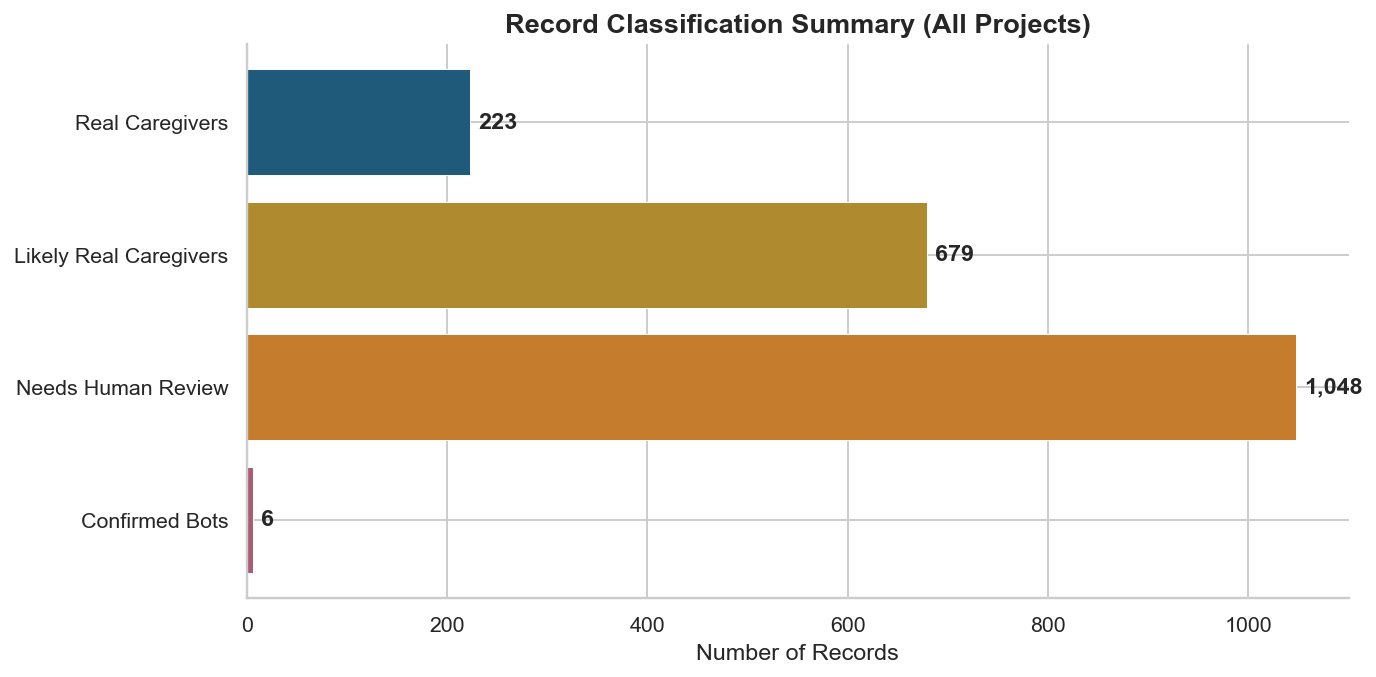

Meeting-ready overview


,Stakeholder Group,Study 1 (4797),Study 2 (4581),All Records,Interpretation
0,Cleared for payment now,153,70,223,Tier 4 pass. No screening rule fired.
1,Low-risk provisional approval,19,660,679,One soft check only. Provisionally safe but st...
2,Needs human review,5,1043,1048,Manual adjudication queue.
3,Confirmed bot / reject,0,6,6,Strongest evidence concentration. Hold payment.
4,Extreme fast (R1 + R2),0,279,279,Cross-cut subset of the hard-check path; not a...
5,Extreme fast with no other hard check,0,276,276,"Broke both timing rules, but no duplicate or l..."


Four-bucket count table behind the chart


,classification,action,clean_4797_n,clean_4797_pct,dirty_4581_n,dirty_4581_pct,total_n,total_pct
0,Real Caregivers,Send Gift Card Now,153,86.4%,70,3.9%,223,11.4%
1,Likely Real Caregivers,Approve for Gift Card,19,10.7%,660,37.1%,679,34.7%
2,Needs Human Review,Hold Pending Adjudication,5,2.8%,1043,58.6%,1048,53.6%
3,Confirmed Bots,Withhold Payment / Block,0,0.0%,6,0.3%,6,0.3%
4,Total,NaN,177,100.0%,1779,100.0%,1956,100.0%


Documented confirmed bot records


,Record ID,project_id,Hard Rules Fired,Soft Rules Fired,Total Rules Fired,Reason for Rejection
0,120,4581,"R1, R2, R8","R3, R4, R6",6/10,Impossibly fast (<11.57 min) + Branching logic...
1,571,4581,"R1, R2, R8","R3, R4, R6",6/10,Impossibly fast (<11.57 min) + Branching logic...
2,1026,4581,"R1, R2, R8","R3, R4, R6",6/10,Impossibly fast (<11.57 min) + Branching logic...
3,182,4581,"R2, R8","R3, R4, R6",5/10,Fast TFA section (<7.85 min) + Branching logic...
4,1774,4581,"R2, R8","R3, R4, R6",5/10,Fast TFA section (<7.85 min) + Branching logic...
5,1678,4581,"R2, R8","R3, R6",4/10,Fast TFA section (<7.85 min) + Branching logic...


In [8]:
fig = plot_category_summary(master_summary)
plt.show()

print("Meeting-ready overview")
display(overview_summary)

print("Four-bucket count table behind the chart")
display(master_summary)

print("Documented confirmed bot records")
display(confirmed_bots)

### A.3 Detailed Sub-Category Breakdown

Within each main category, records are further classified by the **specific rules** that triggered their flag. This shows where the problems cluster and helps prioritise review.


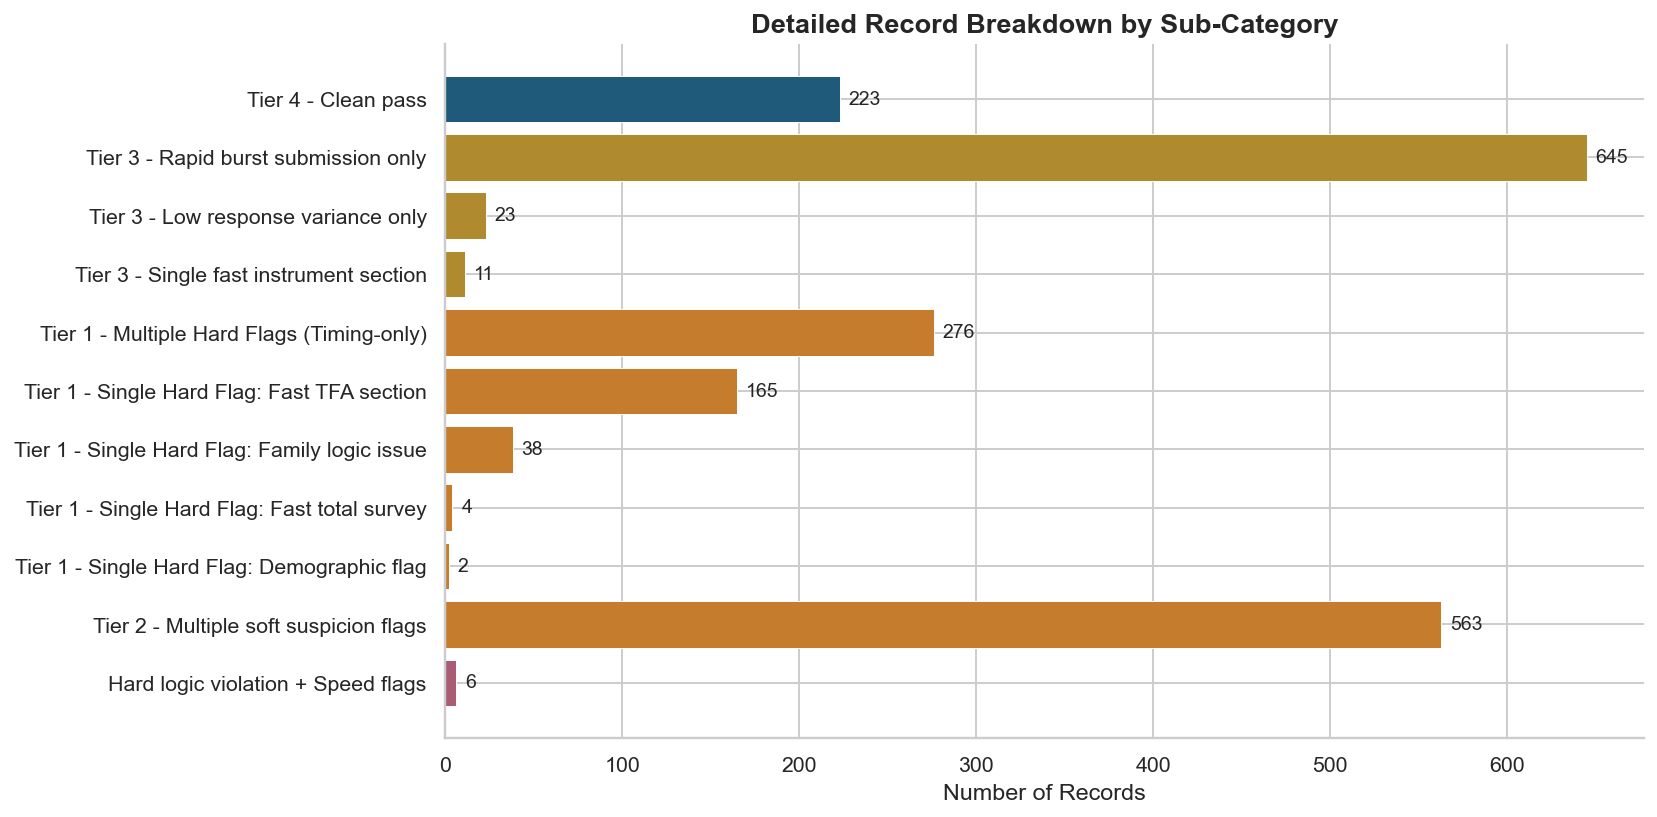

,classification,sub_category_reason,rules_fired,clean_4797_n,dirty_4581_n,total_n,recommended_action
0,Real Caregiver,Tier 4 - Clean pass,None (0 rules),153,70,223,Immediate disbursement
1,Likely Real,Tier 3 - Rapid burst submission only,R6 only,4,641,645,Safe to release
2,Likely Real,Tier 3 - Low response variance only,R4 only,10,13,23,Safe to release
3,Likely Real,Tier 3 - Single fast instrument section,R3 only,5,6,11,Safe to release
4,Needs Review,Tier 1 - Multiple Hard Flags (Timing-only),R1 + R2,0,276,276,Check if genuine fast reader
5,Needs Review,Tier 1 - Single Hard Flag: Fast TFA section,R2 only,0,165,165,Check TFA engagement
6,Needs Review,Tier 1 - Single Hard Flag: Family logic issue,R8 only,0,38,38,Check branching consistency
7,Needs Review,Tier 1 - Single Hard Flag: Fast total survey,R1 only,0,4,4,Check survey duration
8,Needs Review,Tier 1 - Single Hard Flag: Demographic flag,R9 only,2,0,2,Check age / ZIP format
9,Needs Review,Tier 2 - Multiple soft suspicion flags,>=2 of R3/R4/R6/R7,3,560,563,Batch review soft signals


In [9]:
# Detailed sub-category breakdown
fig = plot_detailed_breakdown(detailed_breakdown)
plt.show()

# Display the detailed table
display(detailed_breakdown)


### A.4 Completion Time Distributions

These histograms show how long participants took to complete the survey. The **red dashed line** marks the threshold below which responses are flagged.

- **Left**: Total survey completion time (threshold: 11.57 minutes)
- **Right**: Attitudes section time only (threshold: 7.85 minutes)

Responses below the threshold appear in the leftmost bins — these are the ones flagged by R1 and R2.


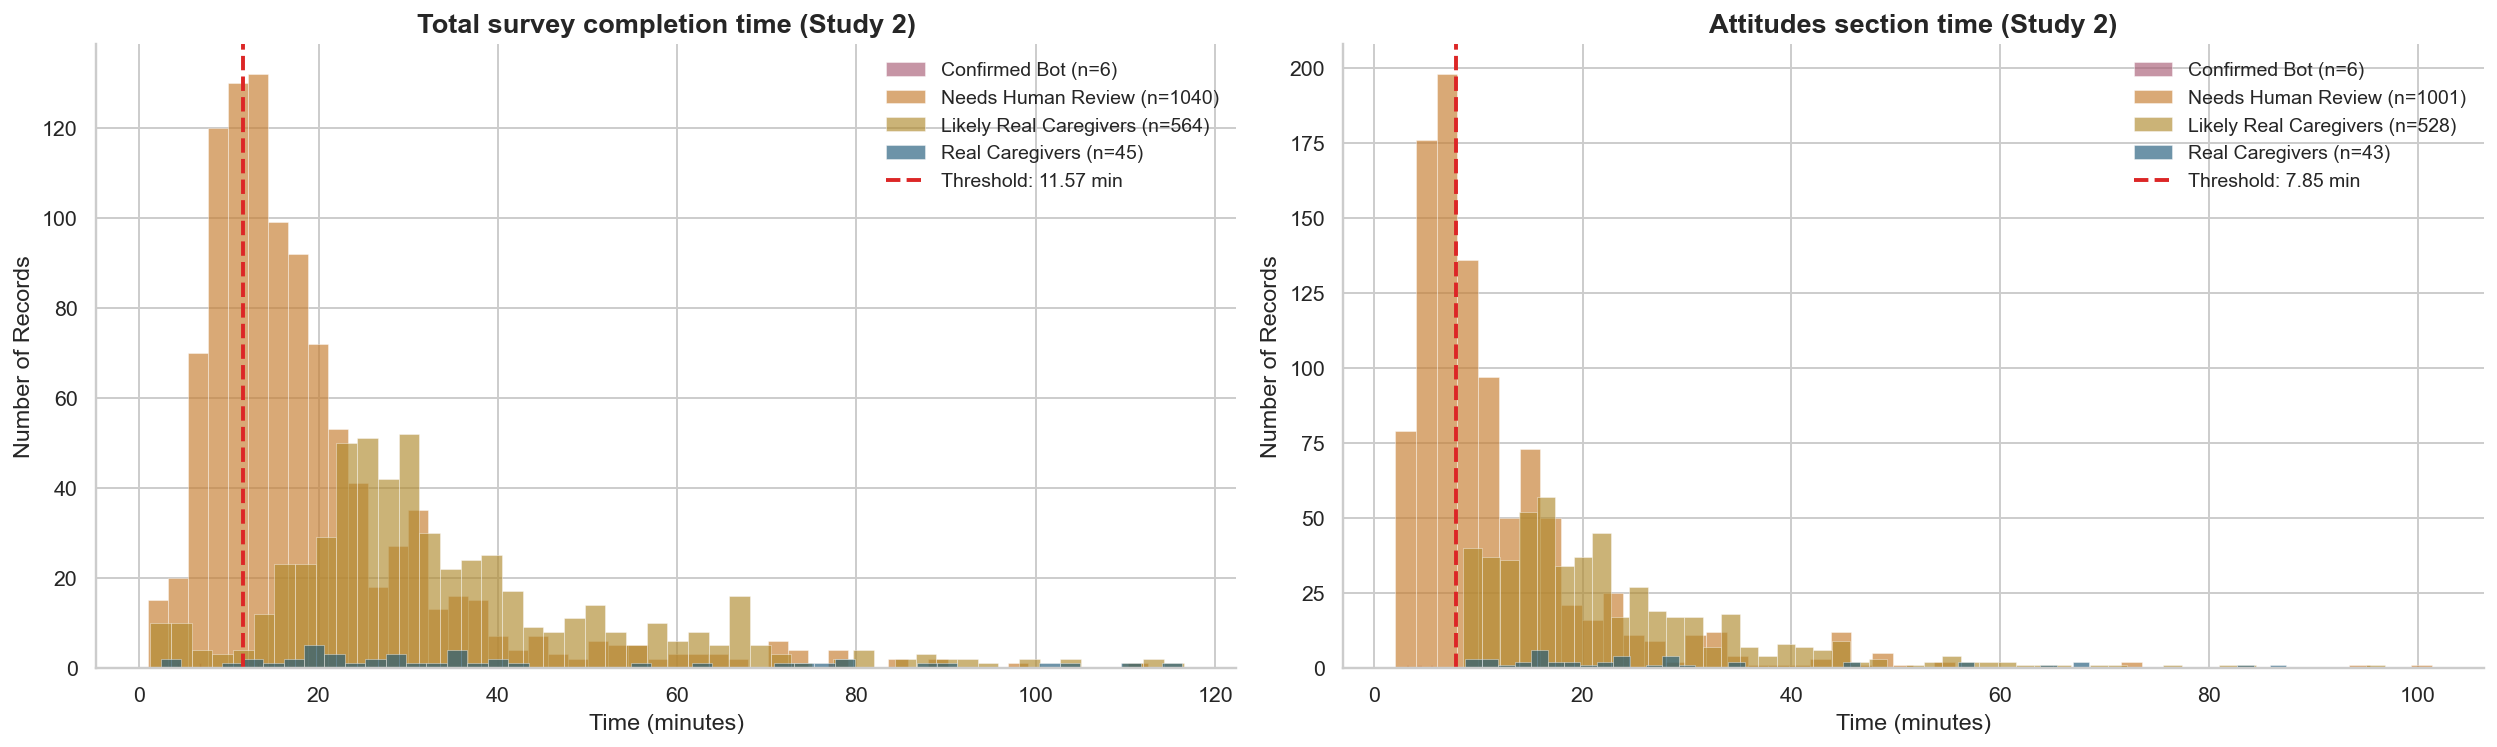

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5.5))

plot_completion_time_histogram(
    study2_records,
    time_col="Total Survey Time (min)",
    threshold_min=11.57,
    title="Total survey completion time (Study 2)",
    ax=ax1,
)

plot_completion_time_histogram(
    study2_records,
    time_col="Attitudes Section Time (min)",
    threshold_min=7.85,
    title="Attitudes section time (Study 2)",
    ax=ax2,
)

plt.tight_layout()
plt.show()

### A.5 Rule Violation Frequency

This chart shows **how many records** triggered each screening rule. Rules are shown with plain-English names to make it clear what each one checks.

- The **most frequently violated** rules appear at the top.
- Rules that fire on very few records may be candidates for threshold adjustment.


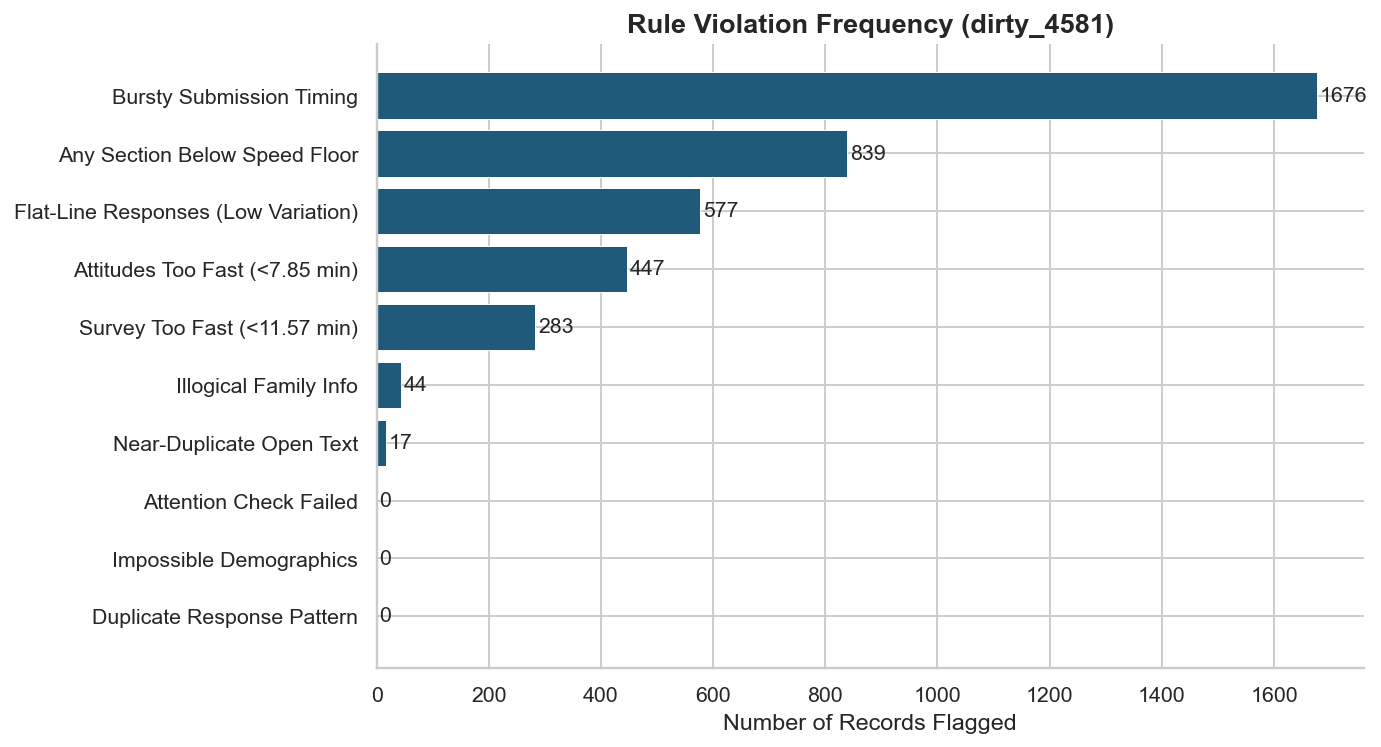

In [11]:
fig = plot_rule_violation_frequency(record_flags, project_filter="dirty_4581")
plt.show()

### A.6 Hard-Check Overlap and the 279 Extreme-Fast Records

This section answers the main timing question from the meeting notes. The heatmap shows which hard checks travel together inside Study 2, and the summary table keeps the most important distinction explicit:

- 279 records broke both timing rules R1 and R2
- 276 of those had no other hard-check signal
- only 3 had both timing violations plus another hard-check trigger

The preview table below is intentionally small and readable so reviewers can see what the extreme-fast sheet in the Excel workbook will look like.

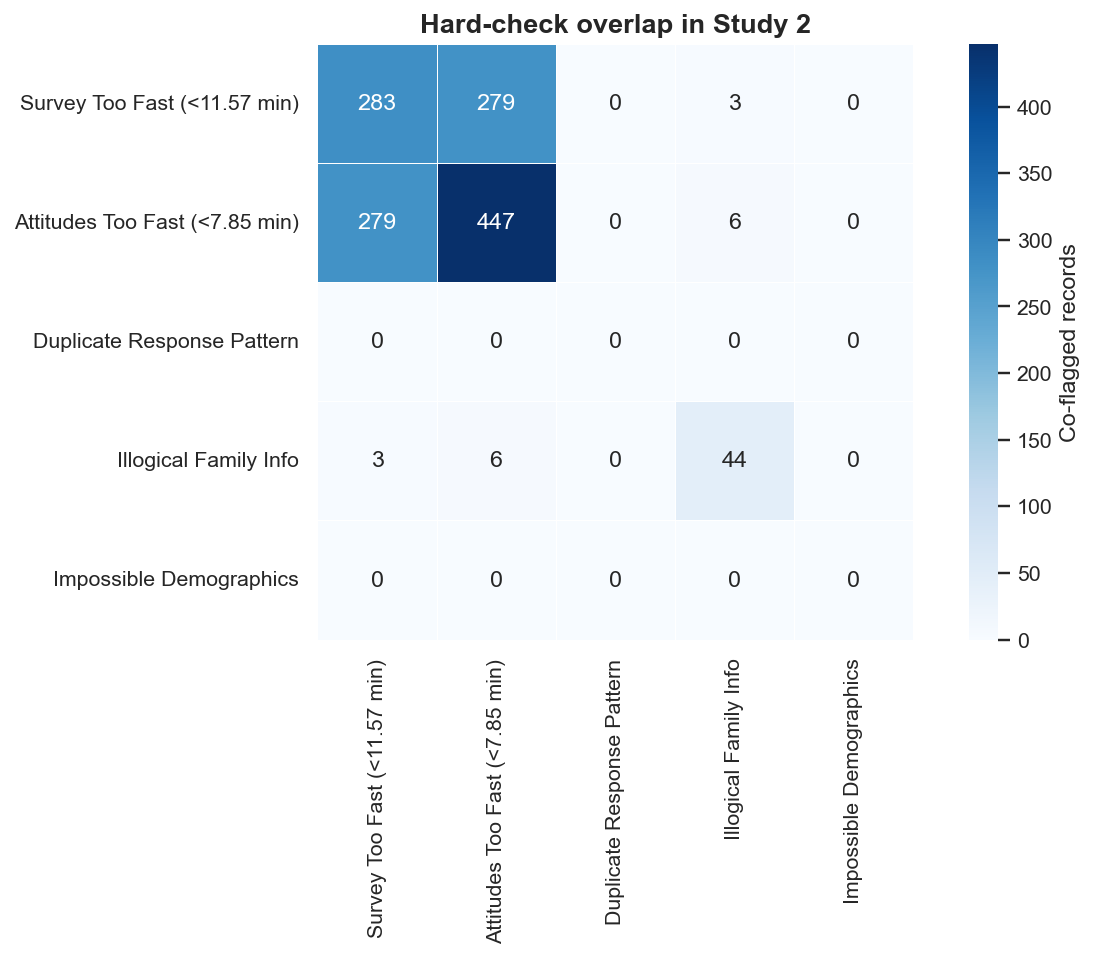

Extreme-fast summary


,Stakeholder Group,Study 1 (4797),Study 2 (4581),All Records,Interpretation
4,Extreme fast (R1 + R2),0,279,279,Cross-cut subset of the hard-check path; not a...
5,Extreme fast with no other hard check,0,276,276,"Broke both timing rules, but no duplicate or l..."


Preview of the extreme-fast export sheet


,Study,Record ID,Stakeholder Bucket,Hard Rules Triggered,Soft Rules Triggered,Total Survey Time (min),Attitudes Section Time (min)
177,Study 2 - Legacy (4581),1026,Confirmed bot / reject,"R1, R2, R8","R3, R4, R6",4.17,2.47
178,Study 2 - Legacy (4581),120,Confirmed bot / reject,"R1, R2, R8","R3, R4, R6",9.86,5.47
182,Study 2 - Legacy (4581),571,Confirmed bot / reject,"R1, R2, R8","R3, R4, R6",9.41,4.27
846,Study 2 - Legacy (4581),1002,Needs human review,"R1, R2","R3, R6",9.08,5.12
850,Study 2 - Legacy (4581),1006,Needs human review,"R1, R2","R3, R4, R6",7.89,4.42
852,Study 2 - Legacy (4581),1008,Needs human review,"R1, R2","R3, R6",9.35,6.05
854,Study 2 - Legacy (4581),1010,Needs human review,"R1, R2","R3, R6",8.70,4.53
866,Study 2 - Legacy (4581),1027,Needs human review,"R1, R2","R3, R6",9.37,5.13
874,Study 2 - Legacy (4581),1038,Needs human review,"R1, R2","R3, R6",9.28,4.40
875,Study 2 - Legacy (4581),1039,Needs human review,"R1, R2","R3, R6",9.22,5.00


In [12]:
fig = plot_rule_overlap_heatmap(record_flags)
plt.show()

extreme_fast_summary = overview_summary.loc[
    overview_summary["Stakeholder Group"].isin(
        ["Extreme fast (R1 + R2)", "Extreme fast with no other hard check"]
    )
].copy()

extreme_fast_preview = extreme_fast_records[
    [
        "Study",
        "Record ID",
        "Stakeholder Bucket",
        "Hard Rules Triggered",
        "Soft Rules Triggered",
        "Total Survey Time (min)",
        "Attitudes Section Time (min)",
    ]
].head(20)

print("Extreme-fast summary")
display(extreme_fast_summary)

print("Preview of the extreme-fast export sheet")
display(extreme_fast_preview)

### A.7 Cleared vs Review Demographics

The next decision question is whether the 223 fully cleared records look materially different from the 1,048 review records on a few easy-to-read demographic signals. This section keeps the comparison intentionally small:

- caregiver age coverage
- gender
- ethnicity
- the most visible race categories

The goal is not to make a causal claim. It is to give reviewers a fast side-by-side check before they decide how much manual review the 1,048-record queue needs. Because the current Study 2 cache does not carry usable caregiver-age values, the age panel shows coverage rather than a misleading age-distribution comparison.

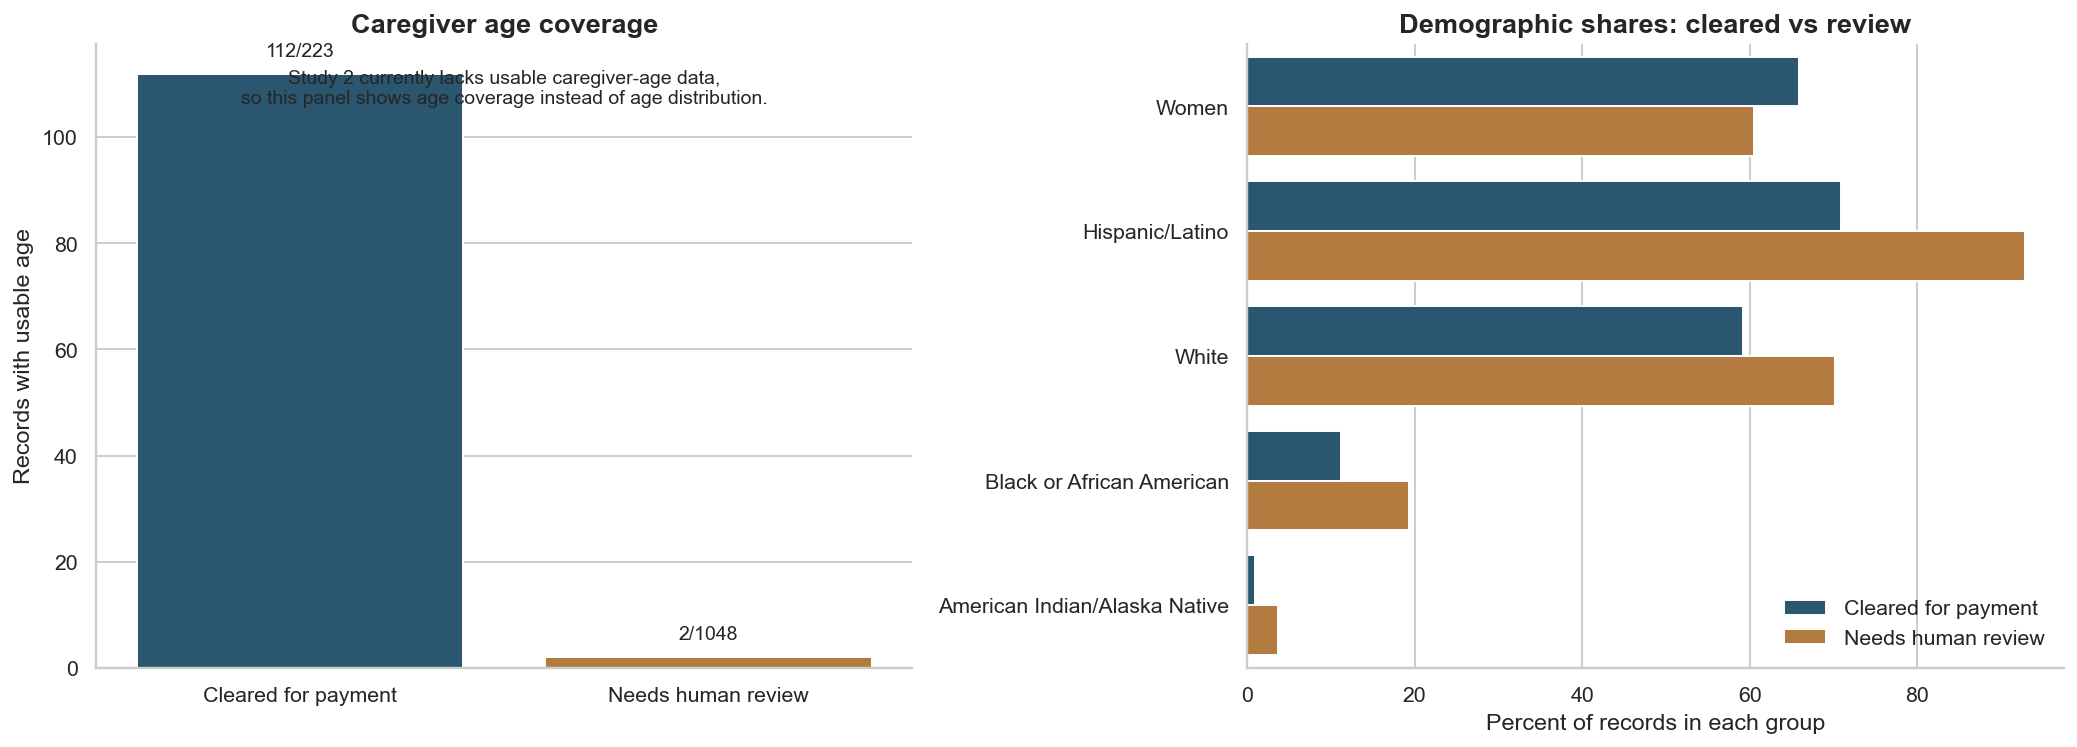

Cleared vs review demographic comparison


,Metric,Cleared for payment (223),Needs human review (1048),Difference
0,Caregiver age available,112/223 records,2/1048 records,Study 2 age comparison is not interpretable fr...
1,Women,147/223 (65.9%),634/1048 (60.5%),5.4 pp
2,Hispanic/Latino,158/223 (70.9%),973/1048 (92.8%),-22.0 pp
3,White,132/223 (59.2%),735/1048 (70.1%),-10.9 pp
4,Black or African American,25/223 (11.2%),203/1048 (19.4%),-8.2 pp
5,American Indian/Alaska Native,2/223 (0.9%),39/1048 (3.7%),-2.8 pp


Cleared-for-payment preview


,Study,Record ID,Stakeholder Bucket,Hard Rules Triggered,Soft Rules Triggered,Total Survey Time (min),Attitudes Section Time (min),Caregiver Age,Gender,Race,Ethnicity
24,Study 1 - Verified (4797),1,Cleared for payment now,None,None,18.87,13.35,32.0,Woman,White,Not Hispanic/Latino
25,Study 1 - Verified (4797),10,Cleared for payment now,None,None,13.70,10.42,49.0,Woman,White,Not Hispanic/Latino
26,Study 1 - Verified (4797),100,Cleared for payment now,None,None,NaN,NaN,NaN,Not answered,Not answered,Not answered
27,Study 1 - Verified (4797),102,Cleared for payment now,None,None,NaN,NaN,NaN,Not answered,Not answered,Not answered
28,Study 1 - Verified (4797),103,Cleared for payment now,None,None,60.50,46.23,39.0,Woman,American Indian/Alaska Native; White,Not Hispanic/Latino
29,Study 1 - Verified (4797),104,Cleared for payment now,None,None,26.10,20.13,34.0,Woman,White,Not Hispanic/Latino
30,Study 1 - Verified (4797),105,Cleared for payment now,None,None,3.65,NaN,NaN,Not answered,Not answered,Not answered
31,Study 1 - Verified (4797),106,Cleared for payment now,None,None,21.38,15.58,39.0,Woman,White,Not Hispanic/Latino
32,Study 1 - Verified (4797),107,Cleared for payment now,None,None,16.45,11.05,35.0,Man,White,Not Hispanic/Latino
33,Study 1 - Verified (4797),108,Cleared for payment now,None,None,29.55,13.48,27.0,Woman,White,Unknown


Needs-review preview


,Study,Record ID,Stakeholder Bucket,Hard Rules Triggered,Soft Rules Triggered,Total Survey Time (min),Attitudes Section Time (min),Caregiver Age,Gender,Race,Ethnicity
19,Study 1 - Verified (4797),101,Needs human review,R9,None,23.67,17.90,33.0,Woman,Black or African American,Not Hispanic/Latino
20,Study 1 - Verified (4797),143,Needs human review,None,"R3, R4",12.05,7.85,NaN,Woman,Black or African American,Not Hispanic/Latino
21,Study 1 - Verified (4797),18,Needs human review,None,"R4, R6",12.58,NaN,NaN,Not answered,Not answered,Not answered
22,Study 1 - Verified (4797),40,Needs human review,None,"R3, R6",1.63,NaN,NaN,Not answered,Not answered,Not answered
23,Study 1 - Verified (4797),89,Needs human review,R9,None,22.13,13.13,39.0,Woman,White,Not Hispanic/Latino
843,Study 2 - Legacy (4581),100,Needs human review,None,"R4, R6",54.72,32.60,NaN,Man,White,Not Hispanic/Latino
844,Study 2 - Legacy (4581),1000,Needs human review,None,"R3, R4, R6",24.29,20.17,NaN,Man,White,Not Hispanic/Latino
845,Study 2 - Legacy (4581),1001,Needs human review,None,"R3, R6",24.10,20.15,NaN,Man,White,Not Hispanic/Latino
846,Study 2 - Legacy (4581),1002,Needs human review,"R1, R2","R3, R6",9.08,5.12,NaN,Woman,Black or African American,Not Hispanic/Latino
847,Study 2 - Legacy (4581),1003,Needs human review,None,"R3, R4, R6",15.76,11.83,NaN,Man,White,Not Hispanic/Latino


In [13]:
fig = plot_clear_vs_review_demographics(stakeholder_records)
plt.show()

print("Cleared vs review demographic comparison")
display(demographic_comparison)

preview_cols = [
    "Study",
    "Record ID",
    "Stakeholder Bucket",
    "Hard Rules Triggered",
    "Soft Rules Triggered",
    "Total Survey Time (min)",
    "Attitudes Section Time (min)",
    "Caregiver Age",
    "Gender",
    "Race",
    "Ethnicity",
]

print("Cleared-for-payment preview")
display(cleared_records[preview_cols].head(10))

print("Needs-review preview")
display(review_records[preview_cols].head(10))

### A.8 Excel Export for Offline Review

The workbook now writes a single stakeholder-ready file with separate sheets for:

1. Overview
2. Workflow Summary
3. All Records
4. Cleared Now
5. Low-Risk Approval
6. Needs Review
7. Extreme Fast R1R2
8. Confirmed Bots
9. 223 vs 1048 Demo
10. Rule Guide
11. Pipeline Diagram

The sheet names intentionally avoid internal variable names so the file can be opened and understood without this notebook.

In [14]:
from openpyxl import load_workbook
import pandas as pd

excel_path = export_stakeholder_excel(OUTPUT_DIR, CACHE_DIR)
print(f"Workbook written: {excel_path.name}")
print(f"File size: {excel_path.stat().st_size / 1024:.1f} KB")

wb = load_workbook(excel_path, read_only=True)
sheet_inventory = pd.DataFrame(
    [
        {"Sheet": sheet, "Rows": wb[sheet].max_row, "Columns": wb[sheet].max_column}
        for sheet in wb.sheetnames
    ]
)
wb.close()

display(sheet_inventory)

Workbook written: ESD_Bot_Analysis_Stakeholder_Summary.xlsx
File size: 401.9 KB


,Sheet,Rows,Columns
0,Overview,7,5
1,Workflow Summary,10,3
2,All Records,1957,24
3,Cleared Now,224,24
4,Low-Risk Approval,680,24
5,Needs Review,1049,24
6,Extreme Fast R1R2,280,24
7,Confirmed Bots,7,24
8,223 vs 1048 Demo,7,4
9,Rule Guide,11,5


## 4. Cluster Metrics on the Selected 4797 Cohort

The remaining sections stay focused on the study objective. After showing what exists in the REDCap caches and what the deterministic trust screen currently flags, the notebook returns to the selected 4797 cohort and summarizes the practical cluster-analysis metrics that are already stable in the project.

In [15]:
fit = fit_named_kmeans(analysis_frame, config)
domains = build_cluster_domains(analysis_frame)
domain_observed_n = domains.notna().sum(axis=1)

screen_table, screen_gap, gap_low, gap_high = _screen_summary(analysis_frame, fit)
cluster_sizes = fit.named_labels.value_counts().reindex(CLUSTER_ORDER)
profile_table = (
    fit.profile_means.T
    .assign(gap=lambda df: df["Higher acceptability"] - df["Conditional acceptability"])
    .sort_values("gap", ascending=False)
)

expected_diag = pd.read_csv(OUTPUT_DIR / "table_3_cluster_diagnostics.csv")
expected_screen = pd.read_csv(OUTPUT_DIR / "table_5_screening_outcome.csv")

validation = pd.DataFrame(
    [
        {"metric": "selected rows", "notebook": len(analysis_frame), "project_export": 135},
        {"metric": "clusterable rows", "notebook": int(fit.eligible.sum()), "project_export": 131},
        {"metric": "higher cluster n", "notebook": int(cluster_sizes["Higher acceptability"]), "project_export": 84},
        {"metric": "conditional cluster n", "notebook": int(cluster_sizes["Conditional acceptability"]), "project_export": 47},
        {
            "metric": "silhouette",
            "notebook": float(fit.silhouette),
            "project_export": float(expected_diag.loc[expected_diag["k"].eq(2), "silhouette"].iloc[0]),
        },
        {
            "metric": "definitely yes gap (pp)",
            "notebook": float(screen_gap),
            "project_export": float(
                expected_screen.loc[expected_screen["cluster"].eq("Higher acceptability"), "definitely_yes_pct"].iloc[0]
                - expected_screen.loc[expected_screen["cluster"].eq("Conditional acceptability"), "definitely_yes_pct"].iloc[0]
            ),
        },
    ]
)
validation["difference"] = validation["notebook"] - validation["project_export"]

metric_summary = pd.DataFrame(
    [
        {"metric": "Clusterable rule", "value": f">= {config['analysis']['minimum_cluster_domains']} of 10 domains observed"},
        {"metric": "Selected analytic rows", "value": len(analysis_frame)},
        {"metric": "Clusterable rows", "value": int(fit.eligible.sum())},
        {"metric": "Clusterable share", "value": f"{fit.eligible.mean() * 100:.1f}%"},
        {"metric": "Higher acceptability n", "value": int(cluster_sizes['Higher acceptability'])},
        {"metric": "Conditional acceptability n", "value": int(cluster_sizes['Conditional acceptability'])},
        {"metric": "Silhouette (k=2)", "value": f"{fit.silhouette:.3f}"},
        {"metric": "Held-out Definitely yes gap", "value": f"{screen_gap:.1f} percentage points"},
        {"metric": "Gap 95% CI", "value": f"{gap_low:.1f} to {gap_high:.1f} percentage points"},
    ]
)

display(metric_summary)
display(validation.round(6))

,metric,value
0,Clusterable rule,>= 8 of 10 domains observed
1,Selected analytic rows,135
2,Clusterable rows,131
3,Clusterable share,97.0%
4,Higher acceptability n,84
5,Conditional acceptability n,47
6,Silhouette (k=2),0.180
7,Held-out Definitely yes gap,42.3 percentage points
8,Gap 95% CI,17.5 to 62.0 percentage points


,metric,notebook,project_export,difference
0,selected rows,135.000000,135.000000,0.0
1,clusterable rows,131.000000,131.000000,0.0
2,higher cluster n,84.000000,84.000000,0.0
3,conditional cluster n,47.000000,47.000000,0.0
4,silhouette,0.180263,0.180263,0.0
5,definitely yes gap (pp),42.340426,42.340426,0.0


## 5. Data Readiness

Before looking at cluster differences, the first question is whether enough of the selected cohort has usable TFA-domain data. The two most practical checks are the cohort flow and the distribution of observed domain counts.

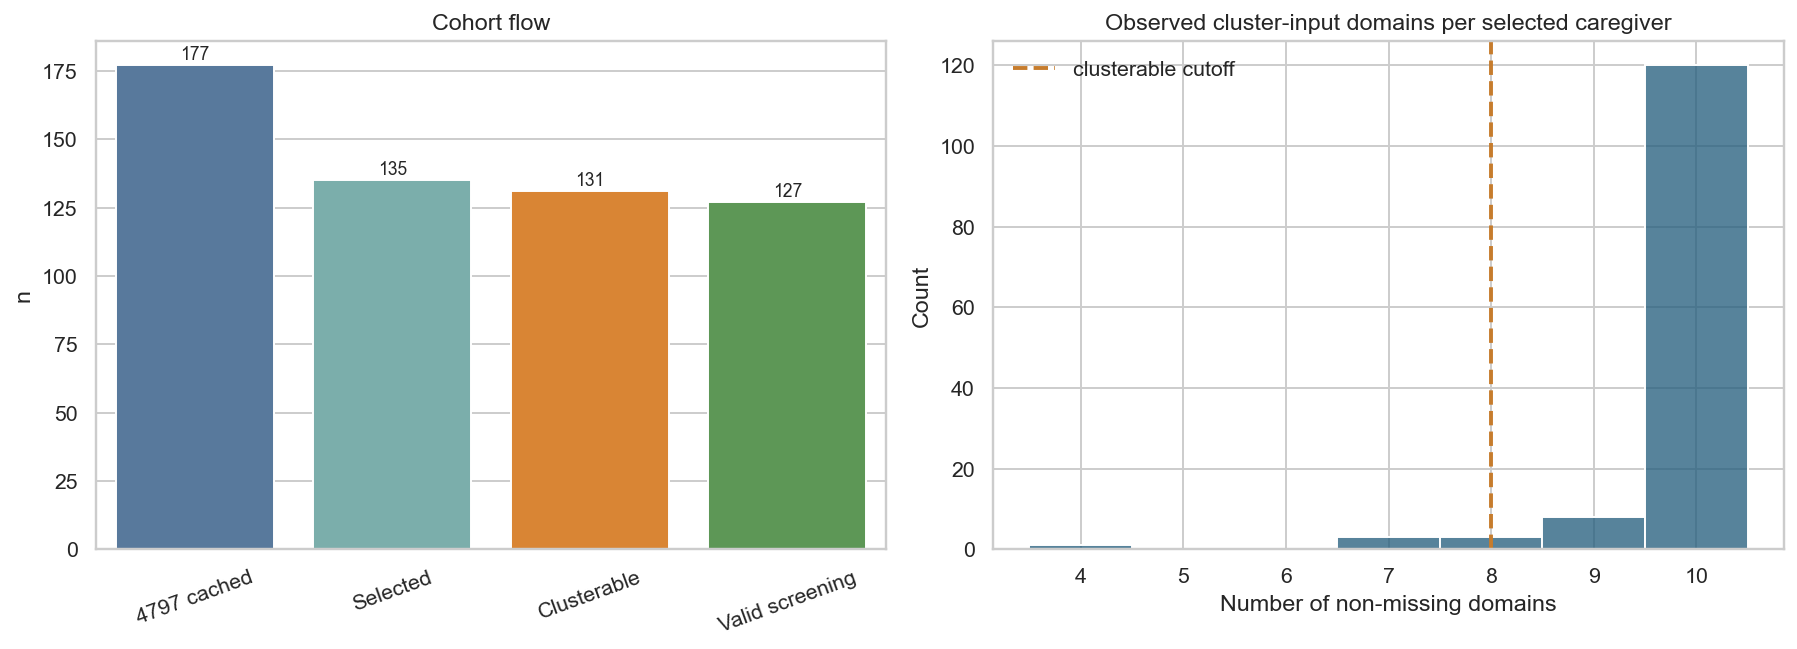

In [16]:
completeness = pd.DataFrame(
    {
        "domains_observed": domain_observed_n,
        "clusterable": domain_observed_n.ge(int(config["analysis"]["minimum_cluster_domains"])),
    }
)

flow_plot = pd.DataFrame(
    [
        {"stage": "4797 cached", "n": len(clean_record)},
        {"stage": "Selected", "n": len(analysis_frame)},
        {"stage": "Clusterable", "n": int(fit.eligible.sum())},
        {"stage": "Valid screening", "n": int(screen_table["valid_n"].sum())},
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.barplot(
    data=flow_plot,
    x="stage",
    y="n",
    hue="stage",
    palette=["#4C78A8", "#72B7B2", "#F58518", "#54A24B"],
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Cohort flow")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)
for index, value in enumerate(flow_plot["n"]):
    axes[0].text(index, value + 2, str(value), ha="center", fontsize=9)

sns.histplot(
    data=completeness,
    x="domains_observed",
    discrete=True,
    color=config["figures"]["blue"],
    ax=axes[1],
)
axes[1].axvline(
    config["analysis"]["minimum_cluster_domains"],
    color=config["figures"]["orange"],
    linestyle="--",
    linewidth=2,
    label="clusterable cutoff",
)
axes[1].set_title("Observed cluster-input domains per selected caregiver")
axes[1].set_xlabel("Number of non-missing domains")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

## 6. Cluster Fit Quality

A simple cluster summary should show three things together: cluster size balance, case-level silhouette spread, and a low-dimensional view of the fitted clusters. The size chart answers whether the split is usable for comparison, the silhouette plot shows how confidently cases sit in their assigned group, and the PCA panel gives a readable geometric view of the same solution.

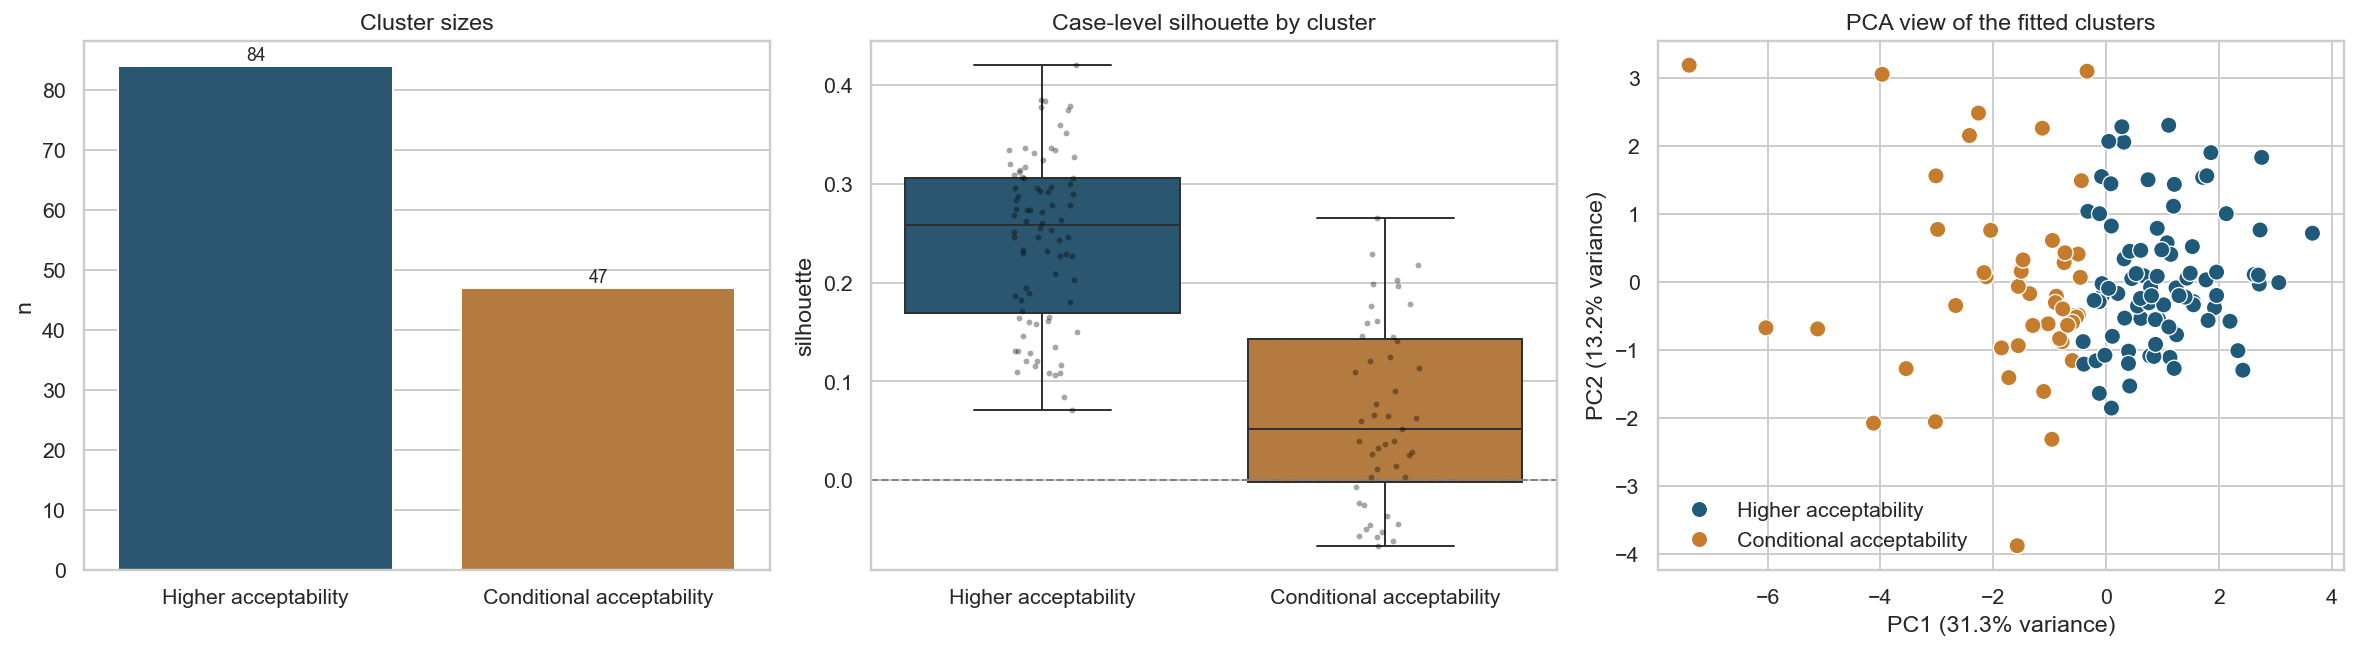

In [17]:
size_table = cluster_sizes.rename_axis("cluster").reset_index(name="n")
silhouette_table = pd.DataFrame(
    {
        "cluster": fit.named_labels.loc[fit.case_silhouette.index].to_numpy(),
        "silhouette": fit.case_silhouette.to_numpy(),
    }
)

pca = PCA(n_components=2, random_state=int(config["analysis"]["seed"]))
pca_scores = pca.fit_transform(fit.X)
pca_table = pd.DataFrame(
    {
        "PC1": pca_scores[:, 0],
        "PC2": pca_scores[:, 1],
        "cluster": fit.named_labels.to_numpy(),
    }
)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

sns.barplot(
    data=size_table,
    x="cluster",
    y="n",
    hue="cluster",
    palette=palette,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Cluster sizes")
axes[0].set_xlabel("")
for index, value in enumerate(size_table["n"]):
    axes[0].text(index, value + 1, str(value), ha="center", fontsize=9)

sns.boxplot(
    data=silhouette_table,
    x="cluster",
    y="silhouette",
    hue="cluster",
    order=CLUSTER_ORDER,
    palette=palette,
    legend=False,
    ax=axes[1],
)
sns.stripplot(
    data=silhouette_table,
    x="cluster",
    y="silhouette",
    order=CLUSTER_ORDER,
    color="black",
    alpha=0.35,
    size=3,
    ax=axes[1],
)
axes[1].axhline(0, color="grey", linestyle="--", linewidth=1)
axes[1].set_title("Case-level silhouette by cluster")
axes[1].set_xlabel("")

sns.scatterplot(
    data=pca_table,
    x="PC1",
    y="PC2",
    hue="cluster",
    hue_order=CLUSTER_ORDER,
    palette=palette,
    s=70,
    ax=axes[2],
)
axes[2].set_title("PCA view of the fitted clusters")
axes[2].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
axes[2].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
axes[2].legend(frameon=False)

plt.tight_layout()
plt.show()

## 7. Cluster-Defining Domains

The most useful profile summary is the domain-level mean difference between clusters. A simple dumbbell chart makes it clear where the separation is largest without hiding the absolute 0 to 100 scale.

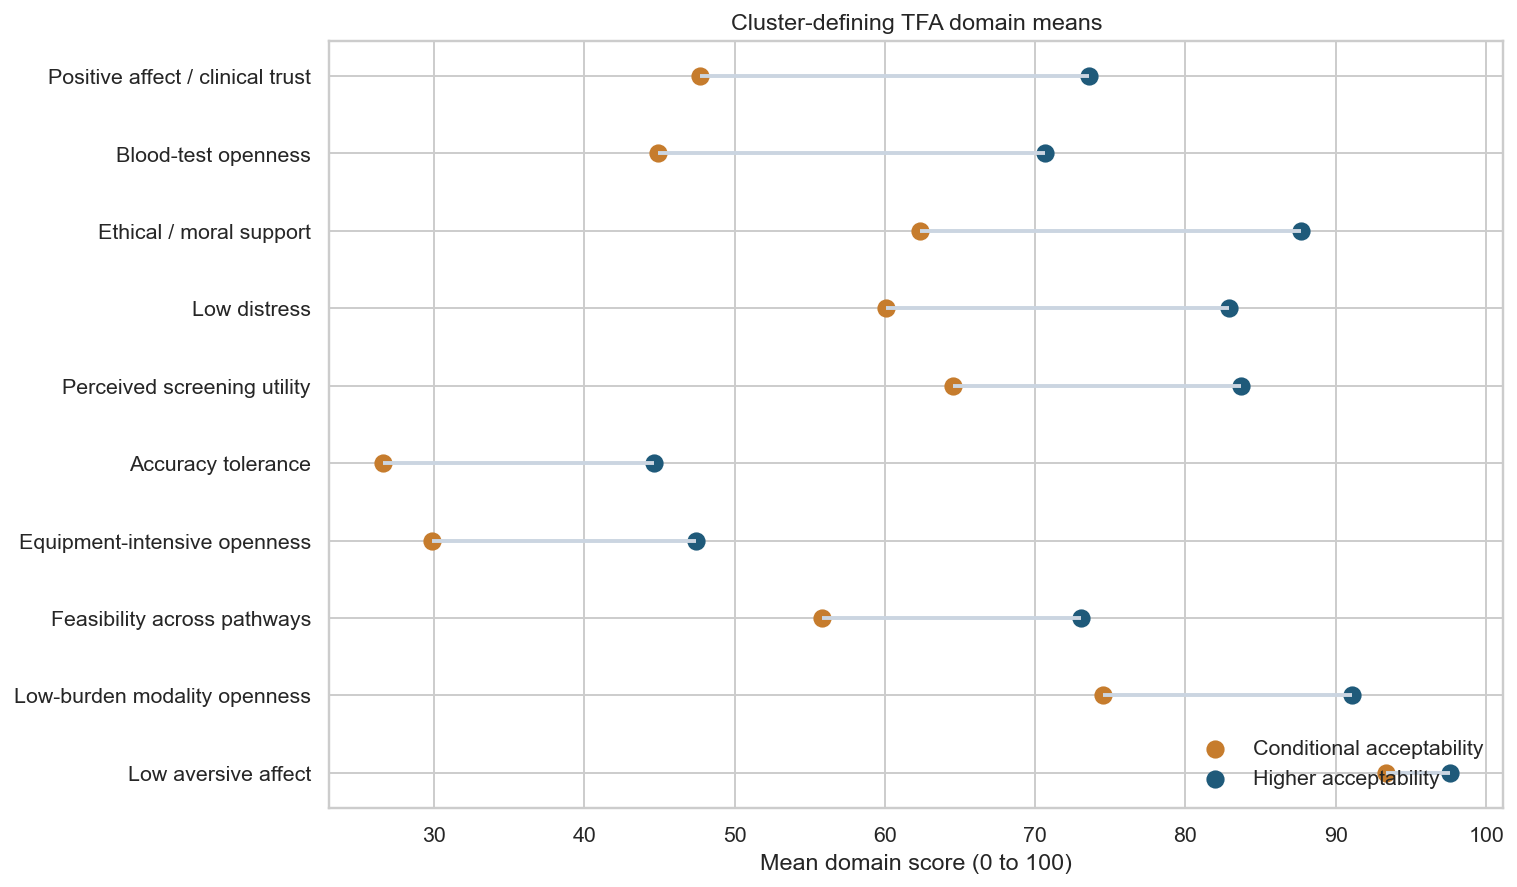

cluster,Higher acceptability,Conditional acceptability,gap
Positive affect / clinical trust,73.6,47.7,25.9
Blood-test openness,70.7,44.9,25.7
Ethical / moral support,87.7,62.3,25.3
Low distress,82.9,60.1,22.8
Perceived screening utility,83.7,64.5,19.2
Accuracy tolerance,44.6,26.6,18.0
Equipment-intensive openness,47.4,29.9,17.5
Feasibility across pathways,73.1,55.8,17.3
Low-burden modality openness,91.1,74.5,16.6
Low aversive affect,97.6,93.4,4.2


In [18]:
plot_table = profile_table.reset_index().rename(columns={"index": "cluster_domain"}).sort_values("gap")

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.hlines(
    plot_table["cluster_domain"],
    plot_table["Conditional acceptability"],
    plot_table["Higher acceptability"],
    color="#CBD5E1",
    linewidth=2,
)
ax.scatter(
    plot_table["Conditional acceptability"],
    plot_table["cluster_domain"],
    color=palette["Conditional acceptability"],
    s=70,
    label="Conditional acceptability",
)
ax.scatter(
    plot_table["Higher acceptability"],
    plot_table["cluster_domain"],
    color=palette["Higher acceptability"],
    s=70,
    label="Higher acceptability",
)
ax.set_title("Cluster-defining TFA domain means")
ax.set_xlabel("Mean domain score (0 to 100)")
ax.legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.show()

display(profile_table.round(1))

## 8. Held-Out Screening Outcome

This is the most direct decision metric in the project because the screening response is held out of the clustering inputs. If the two-cluster solution is useful, the gap in Definitely yes rates should be visible without needing extra model layers.

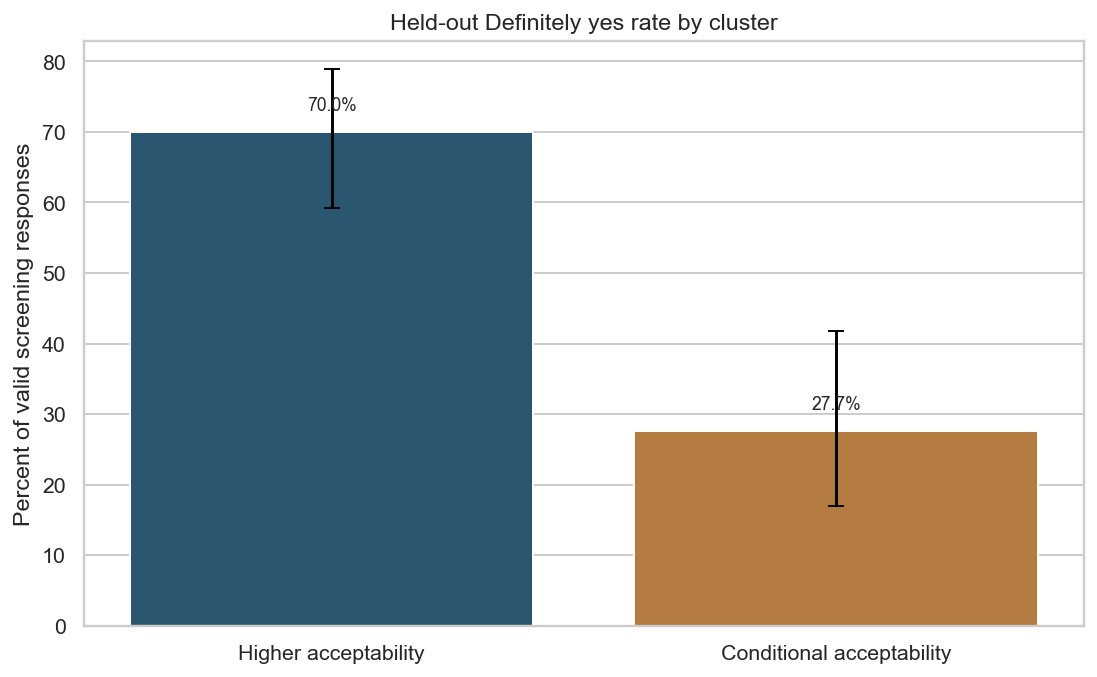

,cluster,valid_n,definitely_yes_n,definitely_yes_pct,wilson_low_pct,wilson_high_pct
0,Higher acceptability,80,56,70.00,59.23,78.94
1,Conditional acceptability,47,13,27.66,16.94,41.76


,metric,value
0,Higher acceptability Definitely yes,70.0% (56/80)
1,Conditional acceptability Definitely yes,27.7% (13/47)
2,Absolute gap,42.3 percentage points
3,Gap 95% interval,17.5 to 62.0 percentage points


In [19]:
screen_plot = screen_table.set_index("cluster").loc[CLUSTER_ORDER].reset_index()
decision_table = pd.DataFrame(
    [
        {"metric": "Higher acceptability Definitely yes", "value": f"{screen_plot.loc[0, 'definitely_yes_pct']:.1f}% ({int(screen_plot.loc[0, 'definitely_yes_n'])}/{int(screen_plot.loc[0, 'valid_n'])})"},
        {"metric": "Conditional acceptability Definitely yes", "value": f"{screen_plot.loc[1, 'definitely_yes_pct']:.1f}% ({int(screen_plot.loc[1, 'definitely_yes_n'])}/{int(screen_plot.loc[1, 'valid_n'])})"},
        {"metric": "Absolute gap", "value": f"{screen_gap:.1f} percentage points"},
        {"metric": "Gap 95% interval", "value": f"{gap_low:.1f} to {gap_high:.1f} percentage points"},
    ]
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=screen_plot,
    x="cluster",
    y="definitely_yes_pct",
    hue="cluster",
    order=CLUSTER_ORDER,
    palette=palette,
    legend=False,
    ax=ax,
)
for index, row in screen_plot.iterrows():
    lower_error = row["definitely_yes_pct"] - row["wilson_low_pct"]
    upper_error = row["wilson_high_pct"] - row["definitely_yes_pct"]
    ax.errorbar(
        index,
        row["definitely_yes_pct"],
        yerr=[[lower_error], [upper_error]],
        fmt="none",
        ecolor="black",
        capsize=4,
    )
    ax.text(index, row["definitely_yes_pct"] + 3, f"{row['definitely_yes_pct']:.1f}%", ha="center", fontsize=9)
ax.set_title("Held-out Definitely yes rate by cluster")
ax.set_xlabel("")
ax.set_ylabel("Percent of valid screening responses")

plt.tight_layout()
plt.show()

display(screen_plot.round(2))
display(decision_table)

## 9. How To Use These Metrics

1. Use the REDCap API snapshot section to show what is actually present in the current project files before making methodological choices.
2. Use the field-availability table to separate what can be screened directly from what cannot be supported by the available data.
3. Use the trust-tier and rule-count section as the grounded fraud summary; it is more defensible than claiming a literal fraud prevalence.
4. Use cluster size balance and silhouette together: the current split is usable and reasonably balanced, but the silhouette is modest, so the clusters are better treated as practical groupings than hard natural types.
5. Use the domain gap table to explain what separates the clusters in plain language.
6. Use the held-out Definitely yes gap as the main decision metric because it stays outside the clustering inputs and is easy to interpret.
7. Use the validation table to confirm that the notebook still matches the project's committed exports when files are updated.